In [1]:
!ls "../datos_cultivos/"

 CHLORELLA-20260126T182532Z-3-001
 Chlorella-20260126T182158Z-3-001
 Haematococcus_verde1-20260126T202441Z-3-001
 Haematococcus_verde2-20260126T213243Z-3-001
'Scenedesmus acutus_ 1_50-20260126T214011Z-3-001'
'Scenedesmus acutus_1_100-20260126T214147Z-3-001'


# Image reading

In [2]:
from pathlib import Path
import numpy as np

In [3]:
TYPES = ["amp", "flr_1", "flr_2", "flr_3", "flu", "mask", "phase"]
class_names = ["Chlorella", "Haematococcus"]

def group7(paths):
    groups = {} # key -> common_img_id, value -> another dictionary with img types, {amp: amp_img, flr_1: flr_1_img, ...}

    for path in paths:
        stem = path.stem  # name without .png
        t = next((t for t in TYPES if stem.endswith("_" + t)), None)
        if t is None:
            continue
        base = stem[:-(len(t) + 1)]  # remove "_type"
        groups.setdefault(base, {})[t] = path # add image to dictionary (or create it if it doesn't already)

    # Return only coplete microalgaes (7/7)
    resultado = []
    for d in groups.values():
        if all(t in d for t in TYPES):
            resultado.append([d[t] for t in TYPES])

    return resultado

def load_dataset(base_dir: Path):
    '''
    class_prefix = {"CH" : 0, # Chlorella
                    "HA" : 1, # Haematococcus
                    "SC" : 2} # Scenedesmus
    '''
    class_prefix = {"CH" : 0, # Chlorella
                    "HA" : 1 # Haematococcus
                   }

    X_paths = []
    y = []

    # Iterate for each folder
    for class_dir in base_dir.iterdir():
        if not class_dir.is_dir():
            continue

        # Only read imgs in folders with prefix of microalgae that we want (Chlorella -> CH, Haematococcus -> HA, ...)
        for prefix, label in class_prefix.items():
            if class_dir.name.upper().startswith(prefix):
                paths = [p for p in class_dir.rglob("class*/*.png")]
                groups = group7(paths)  # lista de [7 paths] en orden TYPES

                for paths7 in groups:
                    if len(paths7) != len(TYPES):
                        continue
                    # Store as string (better for tf.data)
                    X_paths.append([str(p) for p in paths7])
                    y.append(label)

    X_paths = np.asarray(X_paths, dtype=object)  # (N,7)
    y = np.asarray(y, dtype=np.int32)            # (N,)
    return X_paths, y


In [4]:
BASE_DIR = Path("..") / "datos_cultivos"
X_paths, y = load_dataset(BASE_DIR)
print(X_paths.shape, y.shape)  # (N,7) y (N,)

(3743, 7) (3743,)


# Preprocess

In [5]:
idx0 = np.where(y == 0)[0] # Imgs first class
idx1 = np.where(y == 1)[0] # Imgs second class

# Ensure both classes same number of images
n = min(len(idx0), len(idx1))
idx0 = idx0[:n]
idx1 = idx1[:n]

idx = np.concatenate([idx0, idx1])
np.random.shuffle(idx)

X_paths = X_paths[idx]
y = y[idx]

print("Balanced:", np.sum(y==0), np.sum(y==1))

Balanced: 1727 1727


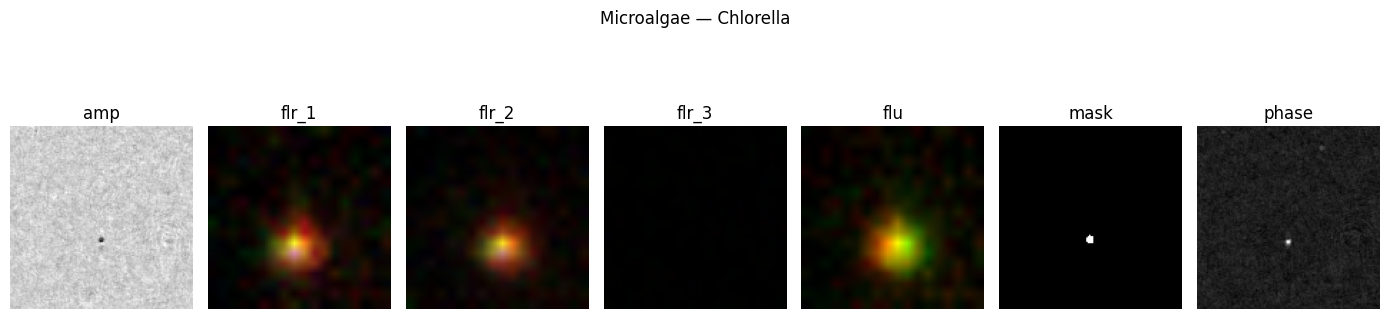

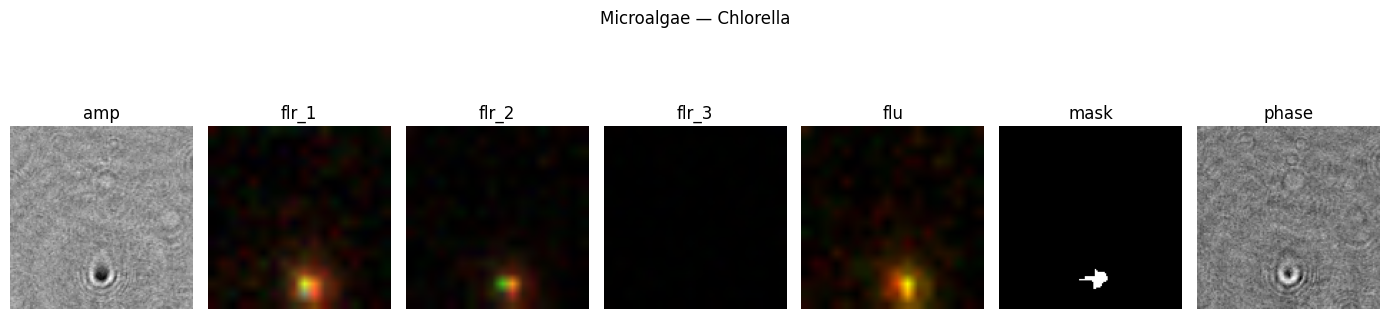

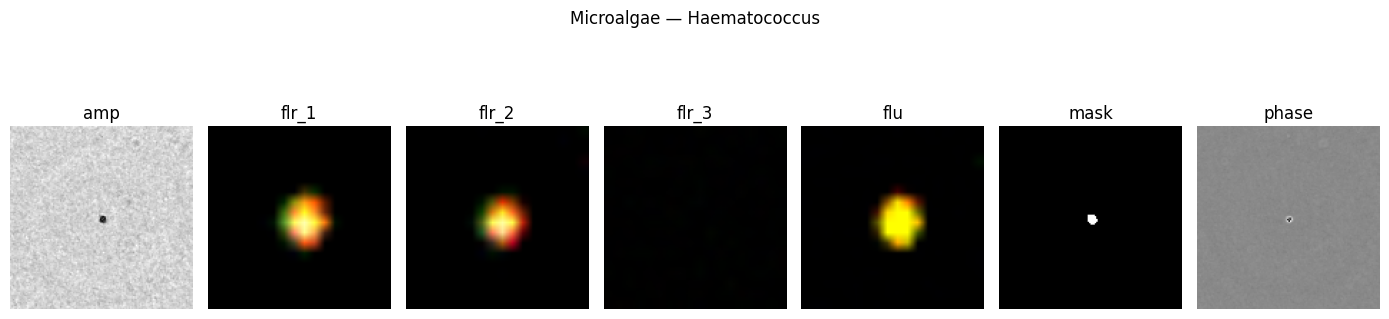

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

def show_microalgae_imgs(paths7, label=None, class_names=None):
    """
    paths7: lista/array de 7 paths (strings o Path)
    label: int (opcional)
    class_names: lista de nombres de clases (opcional)
    """

    plt.figure(figsize=(14, 4))

    for i, (p, t) in enumerate(zip(paths7, TYPES)):
        img = Image.open(p)
        plt.subplot(1, 7, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(t)
        plt.axis("off")

    title = "Microalgae"
    if label is not None and class_names is not None:
        title += f" — {class_names[label]}"

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Show first Chlorella
idx = np.where(y == 0)[0][0] # np.where(y == 0) --> array where y == 0, ej: [0, 2, 5]
show_microalgae_imgs(X_paths[idx], label=y[idx], class_names=class_names)

# Show second Chlorella
idx = np.where(y == 0)[0][1]
show_microalgae_imgs(X_paths[idx], label=y[idx], class_names=class_names)

# Show first Haematococcus
idx = np.where(y == 1)[0][0] 
show_microalgae_imgs(X_paths[idx], label=y[idx], class_names=class_names)

In [7]:
len(X_paths), len(y), y[:5], y[-5:]

(3454,
 3454,
 array([0, 1, 1, 1, 1], dtype=int32),
 array([1, 1, 0, 0, 0], dtype=int32))

# Keras

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

# Asegurar tipos (opcional, pero limpio)
X_paths = np.asarray(X_paths, dtype=object)  # (N,7)
y = np.asarray(y, dtype=np.int32)             # (N,)

# Split train vs temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_paths, y,
    test_size=0.30,          # 30% para val+test
    random_state=42,
    stratify=y
)

# Split temp en validation y test (15% + 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Shapes:
Train: (2417, 7) (2417,)
Val:   (518, 7) (518,)
Test:  (519, 7) (519,)


In [9]:
import tensorflow as tf
import numpy as np

IMG_SIZE = 128
BATCH = 32

MASK_INDEX = TYPES.index("mask")  # 5

def _read_one_png(path, is_mask=False):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_png(img_bytes, channels=1)  # (H,W,1)

    # mask: mejor nearest para no inventar grises
    method = tf.image.ResizeMethod.NEAREST_NEIGHBOR if is_mask else tf.image.ResizeMethod.BILINEAR
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method=method)

    img = tf.cast(img, tf.float32) / 255.0
    return img  # (IMG_SIZE, IMG_SIZE, 1)

def load_7png(paths7, label):
    # paths7: tf.Tensor shape (7,) dtype=tf.string
    imgs = []
    for i in range(7):
        imgs.append(_read_one_png(paths7[i], is_mask=(i == MASK_INDEX)))

    x = tf.concat(imgs, axis=-1)  # (IMG_SIZE, IMG_SIZE, 7)
    return x, label

def make_dataset(X, Y, training=False):
    # Asegurar dtypes correctos SIN bucles Python
    X = np.asarray(X, dtype=str)         # (N,7) strings normales
    Y = np.asarray(Y, dtype=np.int32)    # (N,)

    ds = tf.data.Dataset.from_tensor_slices((X, Y))

    if training:
        ds = ds.shuffle(min(len(X), 2000), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(load_7png, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
test_ds  = make_dataset(X_test,  y_test,  training=False)

In [19]:
# Prueba -----------------------------------------------------------------------------------------------------------------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

NUM_CLASSES = len(class_names)
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 7)

# --- determinismo en VAL/TEST ---
options = tf.data.Options()
options.experimental_deterministic = True
val_ds  = val_ds.with_options(options)
test_ds = test_ds.with_options(options)

def conv_block(x, filters, l2=1e-4, sd=0.15, pool=True):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if pool:
        x = layers.MaxPooling2D()(x)
    if sd and sd > 0:
        x = layers.SpatialDropout2D(sd)(x)
    return x

def make_model_bigger_7ch(l2=1e-4, drop_head=0.4, freeze_bn=True):
    inp = keras.Input(shape=IMG_SHAPE)
    x = inp  # ya está en [0,1]

    x = conv_block(x, 32,  l2=l2, sd=0.10, pool=True)
    x = conv_block(x, 64,  l2=l2, sd=0.15, pool=True)
    x = conv_block(x, 128, l2=l2, sd=0.20, pool=True)
    x = conv_block(x, 256, l2=l2, sd=0.20, pool=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(drop_head)(x)

    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inp, out, name="bigger_7ch")

    if freeze_bn:
        for layer in model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    return model

model = make_model_bigger_7ch(freeze_bn=True)

# --- Warmup LR: sube de 1e-4 -> 1e-3 en 5 épocas ---
class WarmupLR(keras.callbacks.Callback):
    def __init__(self, start_lr=1e-4, target_lr=1e-3, warmup_epochs=5):
        super().__init__()
        self.start_lr = start_lr
        self.target_lr = target_lr
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.start_lr + (self.target_lr - self.start_lr) * (epoch / max(1, self.warmup_epochs - 1))
            keras.backend.set_value(self.model.optimizer.lr, lr)

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # empieza bajo; warmup lo sube
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    WarmupLR(start_lr=1e-4, target_lr=1e-3, warmup_epochs=5),
    keras.callbacks.ModelCheckpoint(
        "best_bigger_7ch.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        min_delta=5e-4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=3e-6,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=callbacks,
    verbose=2
)

best_model = keras.models.load_model("best_bigger_7ch.keras")


Epoch 1/150
76/76 - 9s - loss: 0.7357 - accuracy: 0.5883 - val_loss: 0.6812 - val_accuracy: 0.7201 - lr: 1.0000e-04 - 9s/epoch - 114ms/step
Epoch 2/150
76/76 - 8s - loss: 0.6306 - accuracy: 0.7327 - val_loss: 0.6125 - val_accuracy: 0.7046 - lr: 3.2500e-04 - 8s/epoch - 102ms/step
Epoch 3/150
76/76 - 8s - loss: 0.6020 - accuracy: 0.7687 - val_loss: 0.5510 - val_accuracy: 0.7876 - lr: 5.5000e-04 - 8s/epoch - 103ms/step
Epoch 4/150
76/76 - 8s - loss: 0.5356 - accuracy: 0.7861 - val_loss: 0.5631 - val_accuracy: 0.7896 - lr: 7.7500e-04 - 8s/epoch - 101ms/step
Epoch 5/150
76/76 - 8s - loss: 0.4990 - accuracy: 0.8018 - val_loss: 0.5159 - val_accuracy: 0.7645 - lr: 0.0010 - 8s/epoch - 103ms/step
Epoch 6/150
76/76 - 8s - loss: 0.4902 - accuracy: 0.8146 - val_loss: 0.4886 - val_accuracy: 0.8205 - lr: 0.0010 - 8s/epoch - 102ms/step
Epoch 7/150
76/76 - 8s - loss: 0.4827 - accuracy: 0.8180 - val_loss: 0.5406 - val_accuracy: 0.7645 - lr: 0.0010 - 8s/epoch - 100ms/step
Epoch 8/150
76/76 - 8s - loss: 0

In [14]:
# Prueba2 -----------------------------------------------------------------------------------------------------------------------------------------
# ============================================
# CNN 7 canales (simple) + Warmup LR
# + guardado del mejor modelo
# + selección de tau en VAL
# + evaluación en TEST con rechazo
# ============================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# -----------------------
# Config
# -----------------------
NUM_CLASSES = len(class_names)
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 7)

# (opcional pero recomendable) determinismo en VAL/TEST
options = tf.data.Options()
options.experimental_deterministic = True
val_ds  = val_ds.with_options(options)
test_ds = test_ds.with_options(options)

# -----------------------
# Modelo
# -----------------------
def conv_block(x, filters, l2=1e-4, sd=0.15, pool=True):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if pool:
        x = layers.MaxPooling2D()(x)
    if sd and sd > 0:
        x = layers.SpatialDropout2D(sd)(x)
    return x

def make_model_bigger_7ch(l2=1e-4, drop_head=0.4, freeze_bn=True):
    inp = keras.Input(shape=IMG_SHAPE)
    x = inp  # ya está en [0,1]

    x = conv_block(x, 32,  l2=l2, sd=0.10, pool=True)
    x = conv_block(x, 64,  l2=l2, sd=0.15, pool=True)
    x = conv_block(x, 128, l2=l2, sd=0.20, pool=True)
    x = conv_block(x, 256, l2=l2, sd=0.20, pool=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(drop_head)(x)

    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inp, out, name="bigger_7ch")

    if freeze_bn:
        for layer in model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    return model

model = make_model_bigger_7ch(l2=1e-4, drop_head=0.4, freeze_bn=True)

# -----------------------
# Warmup LR
# -----------------------
class WarmupLR(keras.callbacks.Callback):
    def __init__(self, start_lr=1e-4, target_lr=1e-3, warmup_epochs=5):
        super().__init__()
        self.start_lr = start_lr
        self.target_lr = target_lr
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.start_lr + (self.target_lr - self.start_lr) * (
                epoch / max(1, self.warmup_epochs - 1)
            )
            # compatibilidad vieja/nueva
            try:
                keras.backend.set_value(self.model.optimizer.learning_rate, lr)
            except Exception:
                keras.backend.set_value(self.model.optimizer.lr, lr)

# -----------------------
# Compile + callbacks
# -----------------------
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # warmup lo sube
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    WarmupLR(start_lr=1e-4, target_lr=1e-3, warmup_epochs=5),
    keras.callbacks.ModelCheckpoint(
        "best_bigger_7ch.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        min_delta=5e-4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=3e-6,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=callbacks,
    verbose=2
)

best_model = keras.models.load_model("best_bigger_7ch.keras")

# -----------------------
# Utilidades: sacar probs y elegir tau
# -----------------------
def get_probs_and_labels(model, ds):
    y_true = []
    y_prob = []
    for x, y in ds:
        p = model.predict(x, verbose=0)
        y_prob.append(p)
        y_true.append(y.numpy())
    y_prob = np.concatenate(y_prob, axis=0)
    y_true = np.concatenate(y_true, axis=0)
    return y_prob, y_true

def eval_with_tau(y_true, y_prob, tau):
    y_pred = np.argmax(y_prob, axis=1)
    conf = np.max(y_prob, axis=1)

    reject = conf < tau
    accepted = ~reject

    reject_rate = reject.mean()

    if accepted.sum() == 0:
        return dict(tau=tau, acc=np.nan, reject_rate=reject_rate, accepted=0)

    acc = (y_pred[accepted] == y_true[accepted]).mean()
    return dict(tau=tau, acc=float(acc), reject_rate=float(reject_rate), accepted=int(accepted.sum()))

def pick_tau_for_target_acc(y_true, y_prob, target_acc=0.98, taus=None):
    if taus is None:
        taus = np.linspace(0.50, 0.99, 50)

    best = None
    for tau in taus:
        r = eval_with_tau(y_true, y_prob, float(tau))
        # buscamos acc>=target y con la mayor cobertura (menor reject)
        if np.isfinite(r["acc"]) and r["acc"] >= target_acc:
            if (best is None) or (r["reject_rate"] < best["reject_rate"]):
                best = r

    # si no llega al target, devolvemos el tau que maximiza acc (aunque rechace mucho)
    if best is None:
        best = max((eval_with_tau(y_true, y_prob, float(t)) for t in taus),
                   key=lambda d: (-1 if not np.isfinite(d["acc"]) else d["acc"]))
    return best

# -----------------------
# 1) Elegir tau en VALIDACIÓN
# -----------------------
val_prob, val_true = get_probs_and_labels(best_model, val_ds)

# elige un objetivo: 0.98 suele ser buen punto para “solo cuando está seguro”
best_tau_info = pick_tau_for_target_acc(val_true, val_prob, target_acc=0.98)

tau = best_tau_info["tau"]
print("\n=== TAU elegido en VAL ===")
print(best_tau_info)

# (opcional) imprime una mini tabla para ver tradeoff
print("\n--- Barrido tau (VAL) ---")
for t in [0.60, 0.70, 0.80, 0.90, 0.95]:
    print(eval_with_tau(val_true, val_prob, t))

# -----------------------
# 2) Evaluación en TEST con ese tau
# -----------------------
test_prob, test_true = get_probs_and_labels(best_model, test_ds)
test_res = eval_with_tau(test_true, test_prob, tau)

print("\n=== TEST con rechazo ===")
print(test_res)

# Además, accuracy normal (sin rechazo), por si quieres compararlo
test_acc_no_reject = (np.argmax(test_prob, axis=1) == test_true).mean()
print("\nTEST accuracy SIN rechazo:", float(test_acc_no_reject))


Epoch 1/150
76/76 - 21s - loss: 0.7181 - accuracy: 0.6123 - val_loss: 0.6846 - val_accuracy: 0.6815 - lr: 1.0000e-04 - 21s/epoch - 281ms/step
Epoch 2/150
76/76 - 8s - loss: 0.6177 - accuracy: 0.7460 - val_loss: 0.6173 - val_accuracy: 0.7548 - lr: 3.2500e-04 - 8s/epoch - 99ms/step
Epoch 3/150
76/76 - 7s - loss: 0.5851 - accuracy: 0.7791 - val_loss: 0.5609 - val_accuracy: 0.7568 - lr: 5.5000e-04 - 7s/epoch - 98ms/step
Epoch 4/150
76/76 - 7s - loss: 0.5655 - accuracy: 0.7571 - val_loss: 0.5274 - val_accuracy: 0.7799 - lr: 7.7500e-04 - 7s/epoch - 96ms/step
Epoch 5/150
76/76 - 7s - loss: 0.5205 - accuracy: 0.7998 - val_loss: 0.5115 - val_accuracy: 0.8147 - lr: 0.0010 - 7s/epoch - 95ms/step
Epoch 6/150
76/76 - 7s - loss: 0.5065 - accuracy: 0.7952 - val_loss: 0.4950 - val_accuracy: 0.8127 - lr: 0.0010 - 7s/epoch - 97ms/step
Epoch 7/150
76/76 - 7s - loss: 0.4676 - accuracy: 0.8200 - val_loss: 0.5444 - val_accuracy: 0.7510 - lr: 0.0010 - 7s/epoch - 94ms/step
Epoch 8/150
76/76 - 7s - loss: 0.479

In [22]:
def accuracy_per_class_with_reject(y_true, y_prob, tau, class_names):
    y_pred = np.argmax(y_prob, axis=1)
    conf   = np.max(y_prob, axis=1)

    reject = conf < tau
    accepted = ~reject

    results = {}
    for i, name in enumerate(class_names):
        mask_cls = (y_true == i)
        mask_acc = mask_cls & accepted

        if mask_acc.sum() == 0:
            acc = np.nan
        else:
            acc = (y_pred[mask_acc] == y_true[mask_acc]).mean()

        results[name] = {
            "accuracy": None if np.isnan(acc) else float(acc),
            "accepted": int(mask_acc.sum()),
            "total": int(mask_cls.sum()),
            "reject_rate": float(1 - mask_acc.sum() / mask_cls.sum())
        }
    return results


# --- TEST con rechazo ---
acc_per_class_tau = accuracy_per_class_with_reject(
    test_true, test_prob, tau, class_names
)

# ------------- VALIDATION -------------
print(f"\n=== VAL accuracy por clase (CON rechazo, tau={tau:.2f}) ===")
acc_per_class_val_tau = accuracy_per_class_with_reject(
    val_true, val_prob, tau, class_names
)

for cls, r in acc_per_class_val_tau.items():
    acc_str = "nan" if r["accuracy"] is None else f"{r['accuracy']:.4f}"
    print(
        f"{cls:15s} | acc={acc_str} | "
        f"accepted={r['accepted']:4d}/{r['total']:4d} | "
        f"reject={r['reject_rate']:.2%}"
    )
    
# ------------- TEST -------------
print(f"\n=== TEST accuracy por clase (CON rechazo, tau={tau:.2f}) ===")
for cls, r in acc_per_class_tau.items():
    acc_str = "nan" if r["accuracy"] is None else f"{r['accuracy']:.4f}"
    print(
        f"{cls:15s} | acc={acc_str} | "
        f"accepted={r['accepted']:4d}/{r['total']:4d} | "
        f"reject={r['reject_rate']:.2%}"
    )



=== VAL accuracy por clase (CON rechazo, tau=0.91) ===
Chlorella       | acc=0.9860 | accepted= 214/ 259 | reject=17.37%
Haematococcus   | acc=0.9765 | accepted= 213/ 259 | reject=17.76%

=== TEST accuracy por clase (CON rechazo, tau=0.91) ===
Chlorella       | acc=0.9865 | accepted= 222/ 260 | reject=14.62%
Haematococcus   | acc=0.9733 | accepted= 225/ 259 | reject=13.13%


In [23]:
# Prueba3 ----------------------------------------------------------------------------------------------
# ==========================================================
# MEJORA 1: TAU POR CLASE (calibrado en VAL)
# - Aprende tau_c para cada clase usando predicciones en VAL
# - Evalúa en VAL y TEST con rechazo usando tau por clase
# ==========================================================

import numpy as np

# ----------------------------------------------------------
# Util: métricas por clase con rechazo
# ----------------------------------------------------------
def per_class_report_with_reject(y_true, y_pred, accepted_mask, class_names):
    # y_true, y_pred: (N,)
    # accepted_mask: (N,) bool
    n_classes = len(class_names)

    print("\nPer-class accuracy (solo ACEPTADAS):")
    for c in range(n_classes):
        idx_c = (y_true == c)
        acc_c_mask = accepted_mask & idx_c
        n_c_total = int(idx_c.sum())
        n_c_accpt = int(acc_c_mask.sum())

        if n_c_accpt == 0:
            acc_c = np.nan
        else:
            acc_c = float((y_pred[acc_c_mask] == y_true[acc_c_mask]).mean())

        reject_c = 1.0 - (n_c_accpt / max(1, n_c_total))
        print(f"  {class_names[c]:>15s} | acc={acc_c:.4f} | reject={reject_c:.2%} | accepted={n_c_accpt}/{n_c_total}")

# ----------------------------------------------------------
# 1) Elegir tau por clase (tau_c)
#    Regla: cuando el modelo PREDICE clase c, acepto si conf >= tau_c[c]
#    tau_c se elige en VAL maximizando cobertura dado un target_acc
# ----------------------------------------------------------
def pick_tau_per_class_from_val(y_true, y_prob, class_names, target_acc=0.98, taus=None):
    if taus is None:
        taus = np.linspace(0.50, 0.99, 150)

    y_pred = np.argmax(y_prob, axis=1)
    conf   = np.max(y_prob, axis=1)

    n_classes = len(class_names)
    tau_c = np.zeros(n_classes, dtype=np.float32)

    print("\n=== Elegir tau por clase en VALIDACIÓN ===")

    for c in range(n_classes):
        # índices donde el modelo PREDICE la clase c
        idx = np.where(y_pred == c)[0]

        if len(idx) == 0:
            tau_c[c] = 0.99
            print(f"[VAL] {class_names[c]:>15s} | sin predicciones -> tau=0.990")
            continue

        best = None
        for t in taus:
            accepted = conf[idx] >= t
            if accepted.sum() == 0:
                continue

            # accuracy condicionado a "he predicho c y acepto"
            acc = (y_true[idx][accepted] == c).mean()
            reject_rate = 1.0 - accepted.mean()

            if acc >= target_acc:
                if (best is None) or (reject_rate < best["reject_rate"]):
                    best = dict(tau=float(t), acc=float(acc), reject_rate=float(reject_rate),
                                n_pred=int(len(idx)), n_acc=int(accepted.sum()))

        # si no alcanza target_acc, elegir tau que maximiza acc (aunque rechace más)
        if best is None:
            best = None
            best_acc = -1.0
            for t in taus:
                accepted = conf[idx] >= t
                if accepted.sum() == 0:
                    continue
                acc = (y_true[idx][accepted] == c).mean()
                reject_rate = 1.0 - accepted.mean()
                if acc > best_acc:
                    best_acc = acc
                    best = dict(tau=float(t), acc=float(acc), reject_rate=float(reject_rate),
                                n_pred=int(len(idx)), n_acc=int(accepted.sum()))

        tau_c[c] = best["tau"]
        print(f"[VAL] {class_names[c]:>15s} | tau={best['tau']:.3f} | acc={best['acc']:.4f} "
              f"| reject={best['reject_rate']:.2%} | accepted={best['n_acc']}/{best['n_pred']} (pred=c)")

    return tau_c

# ----------------------------------------------------------
# 2) Evaluar con tau por clase
# ----------------------------------------------------------
def eval_with_tau_per_class(y_true, y_prob, tau_c):
    y_pred = np.argmax(y_prob, axis=1)
    conf   = np.max(y_prob, axis=1)

    # regla de aceptación: conf >= tau_c[pred]
    accepted = conf >= tau_c[y_pred]
    reject_rate = 1.0 - accepted.mean()

    if accepted.sum() == 0:
        return dict(acc=np.nan, reject_rate=float(reject_rate), accepted=0), y_pred, accepted

    acc = float((y_pred[accepted] == y_true[accepted]).mean())
    return dict(acc=acc, reject_rate=float(reject_rate), accepted=int(accepted.sum())), y_pred, accepted


# ===========================
# USO REAL (VAL y TEST)
# ===========================

# (1) tau por clase desde VAL
tau_c = pick_tau_per_class_from_val(val_true, val_prob, class_names, target_acc=0.98)

print("\nTau por clase final:")
for c, t in enumerate(tau_c):
    print(f"  {class_names[c]:>15s}: {t:.3f}")

# (2) evaluar en VAL con tau por clase
val_res_pc, val_pred, val_accpt = eval_with_tau_per_class(val_true, val_prob, tau_c)
print("\n=== VALIDACIÓN con tau_por_clase ===")
print(val_res_pc)
per_class_report_with_reject(val_true, val_pred, val_accpt, class_names)

# (3) evaluar en TEST con tau por clase
test_res_pc, test_pred, test_accpt = eval_with_tau_per_class(test_true, test_prob, tau_c)
print("\n=== TEST con tau_por_clase ===")
print(test_res_pc)
per_class_report_with_reject(test_true, test_pred, test_accpt, class_names)

# (4) comparación rápida: tau global que ya usabas (si existe tau)
try:
    print("\n=== Comparación rápida con tu tau global ===")
    # si tienes tau definido (del pick_tau_for_target_acc anterior)
    test_res_global = eval_with_tau(test_true, test_prob, tau)
    print("TEST tau_global:", test_res_global)
except Exception:
    pass



=== Elegir tau por clase en VALIDACIÓN ===
[VAL]       Chlorella | tau=0.921 | acc=0.9813 | reject=21.03% | accepted=214/271 (pred=c)
[VAL]   Haematococcus | tau=0.842 | acc=0.9823 | reject=8.50% | accepted=226/247 (pred=c)

Tau por clase final:
        Chlorella: 0.921
    Haematococcus: 0.842

=== VALIDACIÓN con tau_por_clase ===
{'acc': 0.9818181818181818, 'reject_rate': 0.1505791505791506, 'accepted': 440}

Per-class accuracy (solo ACEPTADAS):
        Chlorella | acc=0.9813 | reject=17.37% | accepted=214/259
    Haematococcus | acc=0.9823 | reject=12.74% | accepted=226/259

=== TEST con tau_por_clase ===
{'acc': 0.9803063457330415, 'reject_rate': 0.11946050096339111, 'accepted': 457}

Per-class accuracy (solo ACEPTADAS):
        Chlorella | acc=0.9863 | reject=15.77% | accepted=219/260
    Haematococcus | acc=0.9748 | reject=8.11% | accepted=238/259

=== Comparación rápida con tu tau global ===
TEST tau_global: {'tau': 0.91, 'acc': 0.9798657718120806, 'reject_rate': 0.138728323699

### Mejoramos un poquillo usando un tau por clase, me sirve

In [25]:
# Prueba 4 ---------------------------------------------------------------------------------
best_model = keras.models.load_model("best_bigger_7ch.keras")
# ==========================================================
# MEJORA 2 (ALTERNATIVA): Fine-tuning SOLO "HEAD"
# - Congela backbone (conv + BN)
# - Entrena Dense(256) + Dense salida
# - LR bajo, pocas épocas
# ==========================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

best_model = keras.models.load_model("best_bigger_7ch.keras")

# 1) clonar para no tocar el original
head_model = keras.models.clone_model(best_model)
head_model.set_weights(best_model.get_weights())

# 2) congelar TODO
for layer in head_model.layers:
    layer.trainable = False

# 3) descongelar SOLO capas Dense (la "cabeza")
for layer in head_model.layers:
    if isinstance(layer, layers.Dense):
        layer.trainable = True

# (opcional) ver qué entrena
trainable = [l.name for l in head_model.layers if l.trainable]
print("Capas entrenables:", trainable)

# 4) compilar con LR bajo
head_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_head = [
    keras.callbacks.ModelCheckpoint(
        "best_head_tuned.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=3e-6,
        verbose=1
    ),
]

hist_head = head_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_head,
    verbose=2
)

head_best = keras.models.load_model("best_head_tuned.keras")

print("\n=== Evaluación SIN rechazo ===")
print("VAL:", head_best.evaluate(val_ds, verbose=0))
print("TEST:", head_best.evaluate(test_ds, verbose=0))

# Recalcular tau global y tau por clase con tus funciones existentes
val_prob_h, val_true_h = get_probs_and_labels(head_best, val_ds)
test_prob_h, test_true_h = get_probs_and_labels(head_best, test_ds)

best_tau_info_h = pick_tau_for_target_acc(val_true_h, val_prob_h, target_acc=0.98)
tau_h = best_tau_info_h["tau"]
print("\n=== TAU global (head tuned) en VAL ===")
print(best_tau_info_h)

print("\n=== TEST con tau global (head tuned) ===")
print(eval_with_tau(test_true_h, test_prob_h, tau_h))

tau_c_h = pick_tau_per_class_from_val(val_true_h, val_prob_h, class_names, target_acc=0.98)
print("\n=== TEST con tau por clase (head tuned) ===")
test_res_pc_h, test_pred_h, test_accpt_h = eval_with_tau_per_class(test_true_h, test_prob_h, tau_c_h)
print(test_res_pc_h)
per_class_report_with_reject(test_true_h, test_pred_h, test_accpt_h, class_names)


Capas entrenables: ['dense_7', 'dense_8']
Epoch 1/30
76/76 - 8s - loss: 0.1717 - accuracy: 0.9479 - val_loss: 0.1854 - val_accuracy: 0.9459 - lr: 3.0000e-05 - 8s/epoch - 103ms/step
Epoch 2/30
76/76 - 7s - loss: 0.1736 - accuracy: 0.9491 - val_loss: 0.1854 - val_accuracy: 0.9459 - lr: 3.0000e-05 - 7s/epoch - 93ms/step
Epoch 3/30

Epoch 3: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
76/76 - 7s - loss: 0.1771 - accuracy: 0.9483 - val_loss: 0.1854 - val_accuracy: 0.9459 - lr: 3.0000e-05 - 7s/epoch - 93ms/step
Epoch 4/30
76/76 - 7s - loss: 0.1791 - accuracy: 0.9470 - val_loss: 0.1852 - val_accuracy: 0.9479 - lr: 9.0000e-06 - 7s/epoch - 95ms/step
Epoch 5/30
76/76 - 7s - loss: 0.1705 - accuracy: 0.9499 - val_loss: 0.1852 - val_accuracy: 0.9479 - lr: 9.0000e-06 - 7s/epoch - 94ms/step
Epoch 6/30

Epoch 6: ReduceLROnPlateau reducing learning rate to 3e-06.
76/76 - 7s - loss: 0.1748 - accuracy: 0.9487 - val_loss: 0.1852 - val_accuracy: 0.9479 - lr: 9.0000e-06 - 7s/epoch - 9

### No mejora casi nada, descartamos y vamos a otra cosa

In [27]:
# ==========================================================
# MEJORA 3: Temperature Scaling (calibración de softmax)
# - Aprende un escalar T en VALIDACIÓN minimizando NLL
# - Usa probs calibradas para elegir tau y evaluar
# ==========================================================

import numpy as np
import tensorflow as tf

# Usa el modelo que quieras calibrar:
best_model = keras.models.load_model("best_bigger_7ch.keras")
model_cal = best_model  # o head_best

# ----------------------------------------------------------
# 1) Sacar LOGITS aproximados desde probabilidades:
#    Tu modelo da softmax, así que hacemos log(p) como "logits" proxy.
#    (Para calibrar T, esto funciona bien en práctica.)
# ----------------------------------------------------------
def get_probs_and_labels(model, ds):
    y_true = []
    y_prob = []
    for x, y in ds:
        p = model.predict(x, verbose=0)
        y_prob.append(p)
        y_true.append(y.numpy())
    y_prob = np.concatenate(y_prob, axis=0).astype(np.float64)
    y_true = np.concatenate(y_true, axis=0).astype(np.int64)
    return y_prob, y_true

val_prob, val_true = get_probs_and_labels(model_cal, val_ds)
test_prob, test_true = get_probs_and_labels(model_cal, test_ds)

# evitar log(0)
eps = 1e-12
val_logit = np.log(np.clip(val_prob, eps, 1.0))
test_logit = np.log(np.clip(test_prob, eps, 1.0))

# ----------------------------------------------------------
# 2) Aprender T en VALIDACIÓN: minimiza NLL con gradient descent
# ----------------------------------------------------------
def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def nll_from_logits(logits, y_true):
    p = softmax_np(logits)
    return -np.log(np.clip(p[np.arange(len(y_true)), y_true], 1e-12, 1.0)).mean()

def fit_temperature(val_logits, y_true, lr=0.05, steps=300):
    T = tf.Variable(1.0, dtype=tf.float32)

    y = tf.constant(y_true, dtype=tf.int32)
    L = tf.constant(val_logits, dtype=tf.float32)

    opt = tf.keras.optimizers.Adam(learning_rate=lr)

    for _ in range(steps):
        with tf.GradientTape() as tape:
            scaled = L / T
            loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(
                    y, scaled, from_logits=True
                )
            )
        grad = tape.gradient(loss, [T])
        opt.apply_gradients(zip(grad, [T]))
        # clamp para evitar cosas raras
        T.assign(tf.clip_by_value(T, 0.05, 20.0))

    return float(T.numpy())

T = fit_temperature(val_logit, val_true, lr=0.05, steps=400)
print("Temperature T =", T)

# ----------------------------------------------------------
# 3) Calibrar probs
# ----------------------------------------------------------
val_prob_cal = softmax_np(val_logit / T)
test_prob_cal = softmax_np(test_logit / T)

# ----------------------------------------------------------
# 4) Elegir tau en VAL y evaluar en TEST (global + por clase)
# ----------------------------------------------------------
def eval_with_tau(y_true, y_prob, tau):
    y_pred = np.argmax(y_prob, axis=1)
    conf = np.max(y_prob, axis=1)
    accepted = conf >= tau
    reject_rate = 1.0 - accepted.mean()
    if accepted.sum() == 0:
        return dict(tau=tau, acc=np.nan, reject_rate=float(reject_rate), accepted=0)
    acc = float((y_pred[accepted] == y_true[accepted]).mean())
    return dict(tau=float(tau), acc=acc, reject_rate=float(reject_rate), accepted=int(accepted.sum()))

def pick_tau_for_target_acc(y_true, y_prob, target_acc=0.98, taus=None):
    if taus is None:
        taus = np.linspace(0.50, 0.99, 200)

    best = None
    for tau in taus:
        r = eval_with_tau(y_true, y_prob, float(tau))
        if np.isfinite(r["acc"]) and r["acc"] >= target_acc:
            if (best is None) or (r["reject_rate"] < best["reject_rate"]):
                best = r

    if best is None:
        best = max((eval_with_tau(y_true, y_prob, float(t)) for t in taus),
                   key=lambda d: (-1 if not np.isfinite(d["acc"]) else d["acc"]))
    return best

# TAU global calibrado
best_tau_info_cal = pick_tau_for_target_acc(val_true, val_prob_cal, target_acc=0.98)
tau_cal = best_tau_info_cal["tau"]
print("\n=== TAU global (calibrado) en VAL ===")
print(best_tau_info_cal)

print("\n=== TEST con tau global (calibrado) ===")
print(eval_with_tau(test_true, test_prob_cal, tau_cal))

# Si quieres, también tau por clase usando tus funciones de Mejora 1:
tau_c_cal = pick_tau_per_class_from_val(val_true, val_prob_cal, class_names, target_acc=0.98)

print("\n=== TEST con tau por clase (calibrado) ===")
test_res_pc_cal, test_pred_cal, test_accpt_cal = eval_with_tau_per_class(test_true, test_prob_cal, tau_c_cal)
print(test_res_pc_cal)
per_class_report_with_reject(test_true, test_pred_cal, test_accpt_cal, class_names)


Temperature T = 0.9851399660110474

=== TAU global (calibrado) en VAL ===
{'tau': 0.9112060301507539, 'acc': 0.9812646370023419, 'reject_rate': 0.17567567567567566, 'accepted': 427}

=== TEST con tau global (calibrado) ===
{'tau': 0.9112060301507539, 'acc': 0.9799107142857143, 'reject_rate': 0.1368015414258189, 'accepted': 448}

=== Elegir tau por clase en VALIDACIÓN ===
[VAL]       Chlorella | tau=0.921 | acc=0.9814 | reject=20.66% | accepted=215/271 (pred=c)
[VAL]   Haematococcus | tau=0.845 | acc=0.9823 | reject=8.50% | accepted=226/247 (pred=c)

=== TEST con tau por clase (calibrado) ===
{'acc': 0.980349344978166, 'reject_rate': 0.11753371868978801, 'accepted': 458}

Per-class accuracy (solo ACEPTADAS):
        Chlorella | acc=0.9864 | reject=15.38% | accepted=220/260
    Haematococcus | acc=0.9748 | reject=8.11% | accepted=238/259


### Tampoco no aporta gran cosa, descartamos

In [29]:
# Pruebaa 5 -------------------------------------------------------------------------------------------
import numpy as np
import tensorflow as tf
from tensorflow import keras

# ==========================================================
# MEJORA: TTA (Test-Time Augmentation)
# - No reentrena nada
# - Hace K transformaciones por imagen y promedia probs
# - Funciona bien cuando hay variación de orientación/ruido
# ==========================================================

# -----------------------
# 1) Transformaciones TTA
# -----------------------
def tta_transforms(x):
    """
    x: Tensor (B,H,W,C) float32
    Devuelve lista de tensores transformados (misma shape).
    """
    # 4 rotaciones
    r0 = x
    r1 = tf.image.rot90(x, k=1)
    r2 = tf.image.rot90(x, k=2)
    r3 = tf.image.rot90(x, k=3)

    # y sus flips horizontales (8 en total)
    f0 = tf.image.flip_left_right(r0)
    f1 = tf.image.flip_left_right(r1)
    f2 = tf.image.flip_left_right(r2)
    f3 = tf.image.flip_left_right(r3)

    return [r0, r1, r2, r3, f0, f1, f2, f3]

@tf.function
def predict_tta(model, x):
    """
    x: (B,H,W,C)
    Devuelve probs promediadas (B, num_classes)
    """
    xs = tta_transforms(x)
    probs = []
    for xi in xs:
        probs.append(model(xi, training=False))
    p = tf.add_n(probs) / tf.cast(len(probs), tf.float32)
    return p

# -----------------------
# 2) Sacar probs con TTA
# -----------------------
def get_probs_and_labels_tta(model, ds):
    y_true = []
    y_prob = []
    for x, y in ds:
        p = predict_tta(model, x).numpy()
        y_prob.append(p)
        y_true.append(y.numpy())
    y_prob = np.concatenate(y_prob, axis=0)
    y_true = np.concatenate(y_true, axis=0)
    return y_prob, y_true

# -----------------------
# 3) Evaluación completa con TTA
# -----------------------
def eval_tta_pipeline(model, val_ds, test_ds, class_names, target_acc=0.98):
    # VAL probs (TTA)
    val_prob_tta, val_true_tta = get_probs_and_labels_tta(model, val_ds)

    # TEST probs (TTA)
    test_prob_tta, test_true_tta = get_probs_and_labels_tta(model, test_ds)

    # --- SIN rechazo ---
    val_acc_nr = float((np.argmax(val_prob_tta, axis=1) == val_true_tta).mean())
    test_acc_nr = float((np.argmax(test_prob_tta, axis=1) == test_true_tta).mean())

    print("\n=== TTA SIN rechazo ===")
    print("VAL acc:", val_acc_nr)
    print("TEST acc:", test_acc_nr)

    # --- TAU global ---
    best_tau_info = pick_tau_for_target_acc(val_true_tta, val_prob_tta, target_acc=target_acc)
    tau = best_tau_info["tau"]
    print("\n=== TAU global (TTA) en VAL ===")
    print(best_tau_info)

    print("\n=== TEST con tau global (TTA) ===")
    print(eval_with_tau(test_true_tta, test_prob_tta, tau))

    # --- TAU por clase ---
    tau_c = pick_tau_per_class_from_val(val_true_tta, val_prob_tta, class_names, target_acc=target_acc)

    print("\n=== TEST con tau por clase (TTA) ===")
    test_res_pc, test_pred, test_accpt = eval_with_tau_per_class(test_true_tta, test_prob_tta, tau_c)
    print(test_res_pc)
    per_class_report_with_reject(test_true_tta, test_pred, test_accpt, class_names)

    return {
        "val_acc_no_reject": val_acc_nr,
        "test_acc_no_reject": test_acc_nr,
        "tau_global_info": best_tau_info,
        "tau_class": tau_c,
        "test_tau_class": test_res_pc
    }

# ==========================
# USO
# ==========================
best_model = keras.models.load_model("best_bigger_7ch.keras")

res_tta = eval_tta_pipeline(
    best_model,
    val_ds,
    test_ds,
    class_names,
    target_acc=0.98
)



=== TTA SIN rechazo ===
VAL acc: 0.944015444015444
TEST acc: 0.953757225433526

=== TAU global (TTA) en VAL ===
{'tau': 0.9062814070351759, 'acc': 0.9816091954022989, 'reject_rate': 0.16023166023166024, 'accepted': 435}

=== TEST con tau global (TTA) ===
{'tau': 0.9062814070351759, 'acc': 0.9820224719101124, 'reject_rate': 0.1425818882466281, 'accepted': 445}

=== Elegir tau por clase en VALIDACIÓN ===
[VAL]       Chlorella | tau=0.911 | acc=0.9817 | reject=18.28% | accepted=219/268 (pred=c)
[VAL]   Haematococcus | tau=0.895 | acc=0.9814 | reject=14.00% | accepted=215/250 (pred=c)

=== TEST con tau por clase (TTA) ===
{'acc': 0.9821428571428571, 'reject_rate': 0.1368015414258189, 'accepted': 448}

Per-class accuracy (solo ACEPTADAS):
        Chlorella | acc=0.9864 | reject=15.38% | accepted=220/260
    Haematococcus | acc=0.9781 | reject=11.97% | accepted=228/259


### Taambién me quedo casi igual

In [30]:
import numpy as np

# -----------------------
# Eval con 2 umbrales: prob y margen
# -----------------------
def eval_with_prob_and_margin(y_true, y_prob, tau_p, tau_m):
    # y_prob: (N, C)
    y_pred = np.argmax(y_prob, axis=1)

    # top1 y top2
    part = np.partition(y_prob, -2, axis=1)
    p2 = part[:, -2]
    p1 = part[:, -1]
    margin = p1 - p2

    accepted = (p1 >= tau_p) & (margin >= tau_m)
    reject_rate = 1.0 - accepted.mean()

    if accepted.sum() == 0:
        return dict(tau_p=float(tau_p), tau_m=float(tau_m),
                    acc=np.nan, reject_rate=float(reject_rate), accepted=0)

    acc = float((y_pred[accepted] == y_true[accepted]).mean())
    return dict(tau_p=float(tau_p), tau_m=float(tau_m),
                acc=acc, reject_rate=float(reject_rate), accepted=int(accepted.sum()))

# -----------------------
# Buscar (tau_p, tau_m) en VAL para target_acc
# -----------------------
def pick_prob_margin_on_val(y_true, y_prob, target_acc=0.98,
                            taus_p=None, taus_m=None):
    if taus_p is None:
        taus_p = np.linspace(0.70, 0.99, 80)   # rango típico
    if taus_m is None:
        taus_m = np.linspace(0.00, 0.60, 80)   # margen 0..0.6 suele bastar

    best = None
    for tp in taus_p:
        for tm in taus_m:
            r = eval_with_prob_and_margin(y_true, y_prob, float(tp), float(tm))
            if np.isfinite(r["acc"]) and r["acc"] >= target_acc:
                # misma idea: maximizar cobertura => minimizar rechazo
                if (best is None) or (r["reject_rate"] < best["reject_rate"]):
                    best = r

    # si no llega al target, elige el que maximiza acc (y luego minimiza rechazo)
    if best is None:
        best = None
        for tp in taus_p:
            for tm in taus_m:
                r = eval_with_prob_and_margin(y_true, y_prob, float(tp), float(tm))
                if not np.isfinite(r["acc"]):
                    continue
                if (best is None) or (r["acc"] > best["acc"]) or (
                    r["acc"] == best["acc"] and r["reject_rate"] < best["reject_rate"]
                ):
                    best = r

    return best

# ==========================================================
# USO: con tus arrays val_prob, val_true, test_prob, test_true
# (y si usas TTA, usa val_prob_tta/test_prob_tta)
# ==========================================================

best_pm = pick_prob_margin_on_val(val_true, val_prob, target_acc=0.98)
tau_p, tau_m = best_pm["tau_p"], best_pm["tau_m"]

print("\n=== (tau_p, tau_m) elegido en VAL ===")
print(best_pm)

print("\n=== TEST con (tau_p, tau_m) ===")
print(eval_with_prob_and_margin(test_true, test_prob, tau_p, tau_m))



=== (tau_p, tau_m) elegido en VAL ===
{'tau_p': 0.9092405063291139, 'tau_m': 0.0, 'acc': 0.9812646370023419, 'reject_rate': 0.17567567567567566, 'accepted': 427}

=== TEST con (tau_p, tau_m) ===
{'tau_p': 0.9092405063291139, 'tau_m': 0.0, 'acc': 0.9799107142857143, 'reject_rate': 0.1368015414258189, 'accepted': 448}


In [31]:
import numpy as np
import tensorflow as tf

# -----------------------------
# Helpers: modificar dataset
# -----------------------------
def ds_zero_one_channel(ds, ch_idx, n_ch=7):
    """Devuelve un ds donde el canal ch_idx se pone a 0."""
    def _map(x, y):
        # x: (B,H,W,C)
        x = tf.identity(x)
        # máscara [C] con 0 en canal ch y 1 en resto
        m = tf.ones([n_ch], dtype=x.dtype)
        m = tf.tensor_scatter_nd_update(m, indices=[[ch_idx]], updates=[tf.constant(0.0, dtype=x.dtype)])
        x = x * m  # broadcast a (B,H,W,C)
        return x, y
    return ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)

def ds_keep_only_one_channel(ds, ch_idx, n_ch=7):
    """Devuelve un ds donde SOLO queda el canal ch_idx (resto 0)."""
    def _map(x, y):
        x = tf.identity(x)
        m = tf.zeros([n_ch], dtype=x.dtype)
        m = tf.tensor_scatter_nd_update(m, indices=[[ch_idx]], updates=[tf.constant(1.0, dtype=x.dtype)])
        x = x * m
        return x, y
    return ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)

# -----------------------------
# Métricas rápidas (sin rechazo + con rechazo)
# -----------------------------
def acc_no_reject(y_true, y_prob):
    return float((np.argmax(y_prob, axis=1) == y_true).mean())

def eval_suite(y_true, y_prob, tau_global=None, tau_c=None):
    out = {}
    out["acc_no_reject"] = acc_no_reject(y_true, y_prob)
    if tau_global is not None:
        out["with_tau_global"] = eval_with_tau(y_true, y_prob, float(tau_global))
    if tau_c is not None:
        res_pc, _, _ = eval_with_tau_per_class(y_true, y_prob, tau_c)
        out["with_tau_per_class"] = res_pc
    return out

# -----------------------------
# Runner: baseline + ablation
# -----------------------------
def channel_ablation_report(model, val_ds, test_ds, tau_global=None, tau_c=None, n_ch=7):
    # Baseline
    val_prob, val_true = get_probs_and_labels(model, val_ds)
    test_prob, test_true = get_probs_and_labels(model, test_ds)

    base_val = eval_suite(val_true, val_prob, tau_global=tau_global, tau_c=tau_c)
    base_test = eval_suite(test_true, test_prob, tau_global=tau_global, tau_c=tau_c)

    print("\n========================")
    print("BASELINE")
    print("========================")
    print("VAL :", base_val)
    print("TEST:", base_test)

    rows = []

    for ch in range(n_ch):
        # ---- 1) Anular canal ch ----
        val_ds_zero = ds_zero_one_channel(val_ds, ch, n_ch=n_ch)
        test_ds_zero = ds_zero_one_channel(test_ds, ch, n_ch=n_ch)

        val_prob_z, val_true_z = get_probs_and_labels(model, val_ds_zero)
        test_prob_z, test_true_z = get_probs_and_labels(model, test_ds_zero)

        val_res = eval_suite(val_true_z, val_prob_z, tau_global=tau_global, tau_c=tau_c)
        test_res = eval_suite(test_true_z, test_prob_z, tau_global=tau_global, tau_c=tau_c)

        dval = val_res["acc_no_reject"] - base_val["acc_no_reject"]
        dtest = test_res["acc_no_reject"] - base_test["acc_no_reject"]

        rows.append({
            "channel": ch,
            "mode": "zero_channel",
            "val_acc": val_res["acc_no_reject"],
            "test_acc": test_res["acc_no_reject"],
            "d_val_acc": dval,
            "d_test_acc": dtest,
            "val_tau_global": val_res.get("with_tau_global", None),
            "test_tau_global": test_res.get("with_tau_global", None),
            "val_tau_pc": val_res.get("with_tau_per_class", None),
            "test_tau_pc": test_res.get("with_tau_per_class", None),
        })

        print(f"\n--- Canal {ch} puesto a 0 ---")
        print("VAL :", val_res)
        print("TEST:", test_res)

    # ordenar por impacto en TEST (más negativo = más importante)
    rows_sorted = sorted(rows, key=lambda r: r["d_test_acc"])
    print("\n========================")
    print("RESUMEN (ordenado por caída en TEST acc)")
    print("(más negativo => canal más importante)")
    print("========================")
    for r in rows_sorted:
        print(f"ch{r['channel']} | dTEST={r['d_test_acc']:+.4f} | TEST={r['test_acc']:.4f} | dVAL={r['d_val_acc']:+.4f} | VAL={r['val_acc']:.4f}")

    return rows_sorted, (base_val, base_test)

# ---------------------------------------------------------
# USO
# ---------------------------------------------------------
# 1) Define qué tau usar en el análisis (recomendado usar el que ya tengas).
#    Si no quieres rechazo aquí, pon tau_global=None y tau_c=None.
#
# Ejemplo: usando tu tau global previo:
# tau_global = tau  # si ya lo tienes calculado
#
# Ejemplo: usando tau por clase (si ya lo calculaste):
# tau_c = tau_c     # el array de taus por clase
#
# Para empezar, yo usaría TAU GLOBAL o ninguno, y luego miramos rechazo.

tau_global = None
tau_c = None

# Si quieres usar el tau global que ya tenías:
# tau_global = tau

# Si quieres usar tau por clase (de Mejora 1):
# tau_c = tau_c

rows_sorted, baseline = channel_ablation_report(best_model, val_ds, test_ds,
                                                tau_global=tau_global, tau_c=tau_c, n_ch=7)



BASELINE
VAL : {'acc_no_reject': 0.9459459459459459}
TEST: {'acc_no_reject': 0.9518304431599229}

--- Canal 0 puesto a 0 ---
VAL : {'acc_no_reject': 0.5}
TEST: {'acc_no_reject': 0.49903660886319845}

--- Canal 1 puesto a 0 ---
VAL : {'acc_no_reject': 0.6776061776061776}
TEST: {'acc_no_reject': 0.653179190751445}

--- Canal 2 puesto a 0 ---
VAL : {'acc_no_reject': 0.7432432432432432}
TEST: {'acc_no_reject': 0.7263969171483622}

--- Canal 3 puesto a 0 ---
VAL : {'acc_no_reject': 0.9420849420849421}
TEST: {'acc_no_reject': 0.9499036608863198}

--- Canal 4 puesto a 0 ---
VAL : {'acc_no_reject': 0.9247104247104247}
TEST: {'acc_no_reject': 0.9267822736030829}

--- Canal 5 puesto a 0 ---
VAL : {'acc_no_reject': 0.9420849420849421}
TEST: {'acc_no_reject': 0.9441233140655106}

--- Canal 6 puesto a 0 ---
VAL : {'acc_no_reject': 0.5173745173745173}
TEST: {'acc_no_reject': 0.5028901734104047}

RESUMEN (ordenado por caída en TEST acc)
(más negativo => canal más importante)
ch0 | dTEST=-0.4528 | TE

In [32]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# ==========================================================
# CONFIG
# ==========================================================
IMG_SIZE = 128
BATCH = 32
class_names = ["Chlorella", "Haematococcus"]
NUM_CLASSES = len(class_names)

TYPES = ["amp", "flr_1", "flr_2", "flr_3", "flu", "mask", "phase"]

# --- Canales buenos (según tu análisis)
GOOD_CH = [0, 1, 2, 6]  # amp, flr_1, flr_2, phase
GOOD_TYPES = [TYPES[i] for i in GOOD_CH]
print("Usando canales:", GOOD_TYPES)

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, len(GOOD_CH))

# ==========================================================
# TF.DATA: leer solo los canales buenos
# ==========================================================
def _read_one_png(path, is_mask=False):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_png(img_bytes, channels=1)  # (H,W,1)

    method = tf.image.ResizeMethod.NEAREST_NEIGHBOR if is_mask else tf.image.ResizeMethod.BILINEAR
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method=method)

    img = tf.cast(img, tf.float32) / 255.0
    return img

def load_png_selected(paths7, label):
    # paths7: (7,) tf.string
    imgs = []
    for idx in GOOD_CH:
        is_mask = (TYPES[idx] == "mask")  # normalmente aquí será False porque no usamos mask
        imgs.append(_read_one_png(paths7[idx], is_mask=is_mask))

    x = tf.concat(imgs, axis=-1)  # (IMG_SIZE, IMG_SIZE, len(GOOD_CH))
    return x, label

def make_dataset(X, Y, training=False):
    X = np.asarray(X, dtype=str)      # (N,7)
    Y = np.asarray(Y, dtype=np.int32) # (N,)

    ds = tf.data.Dataset.from_tensor_slices((X, Y))

    if training:
        ds = ds.shuffle(min(len(X), 2000), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(load_png_selected, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# crea datasets NUEVOS (usa tus splits ya hechos)
train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
test_ds  = make_dataset(X_test,  y_test,  training=False)

# determinismo en VAL/TEST (recomendable)
options = tf.data.Options()
options.experimental_deterministic = True
val_ds  = val_ds.with_options(options)
test_ds = test_ds.with_options(options)

# ==========================================================
# MODELO (igual que el tuyo, solo cambia input shape)
# ==========================================================
def conv_block(x, filters, l2=1e-4, sd=0.15, pool=True):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if pool:
        x = layers.MaxPooling2D()(x)
    if sd and sd > 0:
        x = layers.SpatialDropout2D(sd)(x)
    return x

def make_model_bigger(l2=1e-4, drop_head=0.4, freeze_bn=True):
    inp = keras.Input(shape=IMG_SHAPE)
    x = inp

    x = conv_block(x, 32,  l2=l2, sd=0.10, pool=True)
    x = conv_block(x, 64,  l2=l2, sd=0.15, pool=True)
    x = conv_block(x, 128, l2=l2, sd=0.20, pool=True)
    x = conv_block(x, 256, l2=l2, sd=0.20, pool=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(drop_head)(x)

    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inp, out, name="bigger_selected_channels")

    if freeze_bn:
        for layer in model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    return model

model = make_model_bigger(l2=1e-4, drop_head=0.4, freeze_bn=True)

# ==========================================================
# WARMUP LR (igual que el tuyo)
# ==========================================================
class WarmupLR(keras.callbacks.Callback):
    def __init__(self, start_lr=1e-4, target_lr=1e-3, warmup_epochs=5):
        super().__init__()
        self.start_lr = start_lr
        self.target_lr = target_lr
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.start_lr + (self.target_lr - self.start_lr) * (
                epoch / max(1, self.warmup_epochs - 1)
            )
            try:
                keras.backend.set_value(self.model.optimizer.learning_rate, lr)
            except Exception:
                keras.backend.set_value(self.model.optimizer.lr, lr)

# ==========================================================
# TRAIN
# ==========================================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    WarmupLR(start_lr=1e-4, target_lr=1e-3, warmup_epochs=5),
    keras.callbacks.ModelCheckpoint(
        "best_selected_channels.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        min_delta=5e-4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=3e-6,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=callbacks,
    verbose=2
)

best_model = keras.models.load_model("best_selected_channels.keras")

# ==========================================================
# PROBS + TAU (igual que el tuyo)
# ==========================================================
def get_probs_and_labels(model, ds):
    y_true = []
    y_prob = []
    for x, y in ds:
        p = model.predict(x, verbose=0)
        y_prob.append(p)
        y_true.append(y.numpy())
    y_prob = np.concatenate(y_prob, axis=0)
    y_true = np.concatenate(y_true, axis=0)
    return y_prob, y_true

def eval_with_tau(y_true, y_prob, tau):
    y_pred = np.argmax(y_prob, axis=1)
    conf = np.max(y_prob, axis=1)

    reject = conf < tau
    accepted = ~reject
    reject_rate = reject.mean()

    if accepted.sum() == 0:
        return dict(tau=float(tau), acc=np.nan, reject_rate=float(reject_rate), accepted=0)

    acc = float((y_pred[accepted] == y_true[accepted]).mean())
    return dict(tau=float(tau), acc=acc, reject_rate=float(reject_rate), accepted=int(accepted.sum()))

def pick_tau_for_target_acc(y_true, y_prob, target_acc=0.98, taus=None):
    if taus is None:
        taus = np.linspace(0.50, 0.99, 200)

    best = None
    for tau in taus:
        r = eval_with_tau(y_true, y_prob, float(tau))
        if np.isfinite(r["acc"]) and r["acc"] >= target_acc:
            if (best is None) or (r["reject_rate"] < best["reject_rate"]):
                best = r

    if best is None:
        best = max((eval_with_tau(y_true, y_prob, float(t)) for t in taus),
                   key=lambda d: (-1 if not np.isfinite(d["acc"]) else d["acc"]))
    return best

# 1) tau en VAL
val_prob, val_true = get_probs_and_labels(best_model, val_ds)
best_tau_info = pick_tau_for_target_acc(val_true, val_prob, target_acc=0.98)
tau = best_tau_info["tau"]

print("\n=== TAU elegido en VAL ===")
print(best_tau_info)

# 2) TEST
test_prob, test_true = get_probs_and_labels(best_model, test_ds)

print("\n=== TEST con rechazo ===")
print(eval_with_tau(test_true, test_prob, tau))

test_acc_no_reject = float((np.argmax(test_prob, axis=1) == test_true).mean())
print("\nTEST accuracy SIN rechazo:", test_acc_no_reject)


Usando canales: ['amp', 'flr_1', 'flr_2', 'phase']
Epoch 1/150
76/76 - 6s - loss: 0.7259 - accuracy: 0.5933 - val_loss: 0.6939 - val_accuracy: 0.6757 - lr: 1.0000e-04 - 6s/epoch - 78ms/step
Epoch 2/150
76/76 - 4s - loss: 0.6753 - accuracy: 0.6434 - val_loss: 0.6941 - val_accuracy: 0.6544 - lr: 3.2500e-04 - 4s/epoch - 57ms/step
Epoch 3/150
76/76 - 4s - loss: 0.6167 - accuracy: 0.7174 - val_loss: 0.5672 - val_accuracy: 0.7857 - lr: 5.5000e-04 - 4s/epoch - 57ms/step
Epoch 4/150
76/76 - 4s - loss: 0.5573 - accuracy: 0.7952 - val_loss: 0.5056 - val_accuracy: 0.8108 - lr: 7.7500e-04 - 4s/epoch - 58ms/step
Epoch 5/150
76/76 - 5s - loss: 0.5189 - accuracy: 0.8105 - val_loss: 0.4855 - val_accuracy: 0.8185 - lr: 0.0010 - 5s/epoch - 59ms/step
Epoch 6/150
76/76 - 4s - loss: 0.4595 - accuracy: 0.8225 - val_loss: 0.4830 - val_accuracy: 0.8185 - lr: 0.0010 - 4s/epoch - 57ms/step
Epoch 7/150
76/76 - 4s - loss: 0.4330 - accuracy: 0.8312 - val_loss: 0.4459 - val_accuracy: 0.8340 - lr: 0.0010 - 4s/epoch 

In [35]:
print(best_model.name, best_model.input_shape)
val_prob, val_true = get_probs_and_labels(best_model, val_ds)
test_prob, test_true = get_probs_and_labels(best_model, test_ds)

print("VAL@14%:", eval_at_reject(val_true, val_prob, 0.14))
print("TEST@14%:", eval_at_reject(test_true, test_prob, 0.14))


bigger_selected_channels (None, 128, 128, 4)
VAL@14%: {'tau': 0.8826219689846039, 'acc': 0.9730337078651685, 'reject_rate': 0.14092664092664092, 'accepted': 445, 'target_reject': 0.14}
TEST@14%: {'tau': 0.8907155871391297, 'acc': 0.9820627802690582, 'reject_rate': 0.14065510597302505, 'accepted': 446, 'target_reject': 0.14}


In [36]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# ==========================================================
# CONFIG
# ==========================================================
IMG_SIZE = 128
BATCH = 32
class_names = ["Chlorella", "Haematococcus"]
NUM_CLASSES = len(class_names)

TYPES = ["amp", "flr_1", "flr_2", "flr_3", "flu", "mask", "phase"]

# --- Canales a usar (5ch)
GOOD_CH = [0, 1, 2, 4, 6]  # amp, flr_1, flr_2, flu, phase
GOOD_TYPES = [TYPES[i] for i in GOOD_CH]
print("Usando canales:", GOOD_TYPES)

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, len(GOOD_CH))

# ==========================================================
# TF.DATA: leer solo los canales seleccionados
# ==========================================================
MASK_INDEX = TYPES.index("mask")  # 5

def _read_one_png(path, is_mask=False):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_png(img_bytes, channels=1)  # (H,W,1)

    method = tf.image.ResizeMethod.NEAREST_NEIGHBOR if is_mask else tf.image.ResizeMethod.BILINEAR
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method=method)

    img = tf.cast(img, tf.float32) / 255.0
    return img

def load_png_selected(paths7, label):
    imgs = []
    for idx in GOOD_CH:
        imgs.append(_read_one_png(paths7[idx], is_mask=(idx == MASK_INDEX)))
    x = tf.concat(imgs, axis=-1)  # (IMG_SIZE, IMG_SIZE, len(GOOD_CH))
    return x, label

def make_dataset(X, Y, training=False):
    X = np.asarray(X, dtype=str)      # (N,7)
    Y = np.asarray(Y, dtype=np.int32) # (N,)

    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if training:
        ds = ds.shuffle(min(len(X), 2000), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(load_png_selected, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

# crea datasets NUEVOS (usa tus splits ya hechos)
train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
test_ds  = make_dataset(X_test,  y_test,  training=False)

# determinismo en VAL/TEST (recomendable)
options = tf.data.Options()
options.experimental_deterministic = True
val_ds  = val_ds.with_options(options)
test_ds = test_ds.with_options(options)

# ==========================================================
# MODELO (igual que el tuyo, solo cambia input shape)
# ==========================================================
def conv_block(x, filters, l2=1e-4, sd=0.15, pool=True):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if pool:
        x = layers.MaxPooling2D()(x)
    if sd and sd > 0:
        x = layers.SpatialDropout2D(sd)(x)
    return x

def make_model_bigger(l2=1e-4, drop_head=0.4, freeze_bn=True):
    inp = keras.Input(shape=IMG_SHAPE)
    x = inp

    x = conv_block(x, 32,  l2=l2, sd=0.10, pool=True)
    x = conv_block(x, 64,  l2=l2, sd=0.15, pool=True)
    x = conv_block(x, 128, l2=l2, sd=0.20, pool=True)
    x = conv_block(x, 256, l2=l2, sd=0.20, pool=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(drop_head)(x)

    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inp, out, name="bigger_selected_channels_5ch")

    if freeze_bn:
        for layer in model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
    return model

model = make_model_bigger(l2=1e-4, drop_head=0.4, freeze_bn=True)

# ==========================================================
# WARMUP LR
# ==========================================================
class WarmupLR(keras.callbacks.Callback):
    def __init__(self, start_lr=1e-4, target_lr=1e-3, warmup_epochs=5):
        super().__init__()
        self.start_lr = start_lr
        self.target_lr = target_lr
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.start_lr + (self.target_lr - self.start_lr) * (
                epoch / max(1, self.warmup_epochs - 1)
            )
            try:
                keras.backend.set_value(self.model.optimizer.learning_rate, lr)
            except Exception:
                keras.backend.set_value(self.model.optimizer.lr, lr)

# ==========================================================
# TRAIN
# ==========================================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    WarmupLR(start_lr=1e-4, target_lr=1e-3, warmup_epochs=5),
    keras.callbacks.ModelCheckpoint(
        "best_selected_channels_5ch.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        min_delta=5e-4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=3e-6,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=callbacks,
    verbose=2
)

best_model_5ch = keras.models.load_model("best_selected_channels_5ch.keras")
print(best_model_5ch.name, best_model_5ch.input_shape)

# ==========================================================
# EVAL helpers
# ==========================================================
def get_probs_and_labels(model, ds):
    y_true = []
    y_prob = []
    for x, y in ds:
        p = model.predict(x, verbose=0)
        y_prob.append(p)
        y_true.append(y.numpy())
    y_prob = np.concatenate(y_prob, axis=0)
    y_true = np.concatenate(y_true, axis=0)
    return y_prob, y_true

def eval_with_tau(y_true, y_prob, tau):
    y_pred = np.argmax(y_prob, axis=1)
    conf = np.max(y_prob, axis=1)
    accepted = conf >= tau
    reject_rate = 1.0 - accepted.mean()
    if accepted.sum() == 0:
        return dict(tau=float(tau), acc=np.nan, reject_rate=float(reject_rate), accepted=0)
    acc = float((y_pred[accepted] == y_true[accepted]).mean())
    return dict(tau=float(tau), acc=acc, reject_rate=float(reject_rate), accepted=int(accepted.sum()))

def tau_for_target_reject(y_prob, target_reject=0.14):
    conf = np.max(y_prob, axis=1)
    # Queremos reject ~= target_reject => aceptar fraction = 1-target
    q = target_reject
    return float(np.quantile(conf, q))  # umbral tal que conf < tau ocurre ~q

def eval_at_reject(y_true, y_prob, target_reject=0.14):
    tau = tau_for_target_reject(y_prob, target_reject)
    r = eval_with_tau(y_true, y_prob, tau)
    r["target_reject"] = float(target_reject)
    return r

# ==========================================================
# PROBS + evaluación @ 14% reject (VAL y TEST)
# ==========================================================
val_prob_5, val_true_5 = get_probs_and_labels(best_model_5ch, val_ds)
test_prob_5, test_true_5 = get_probs_and_labels(best_model_5ch, test_ds)

print("VAL@14%:", eval_at_reject(val_true_5, val_prob_5, 0.14))
print("TEST@14%:", eval_at_reject(test_true_5, test_prob_5, 0.14))

val_acc_no_reject = float((np.argmax(val_prob_5, axis=1) == val_true_5).mean())
test_acc_no_reject = float((np.argmax(test_prob_5, axis=1) == test_true_5).mean())
print("VAL acc no reject:", val_acc_no_reject)
print("TEST acc no reject:", test_acc_no_reject)


Usando canales: ['amp', 'flr_1', 'flr_2', 'flu', 'phase']
Epoch 1/150
76/76 - 8s - loss: 0.7277 - accuracy: 0.5887 - val_loss: 0.7064 - val_accuracy: 0.6795 - lr: 1.0000e-04 - 8s/epoch - 105ms/step
Epoch 2/150
76/76 - 5s - loss: 0.6775 - accuracy: 0.6425 - val_loss: 0.6858 - val_accuracy: 0.6660 - lr: 3.2500e-04 - 5s/epoch - 71ms/step
Epoch 3/150
76/76 - 5s - loss: 0.5725 - accuracy: 0.7563 - val_loss: 0.5574 - val_accuracy: 0.7683 - lr: 5.5000e-04 - 5s/epoch - 71ms/step
Epoch 4/150
76/76 - 5s - loss: 0.5060 - accuracy: 0.8064 - val_loss: 0.5452 - val_accuracy: 0.8089 - lr: 7.7500e-04 - 5s/epoch - 72ms/step
Epoch 5/150
76/76 - 5s - loss: 0.4889 - accuracy: 0.8163 - val_loss: 0.4692 - val_accuracy: 0.8185 - lr: 0.0010 - 5s/epoch - 70ms/step
Epoch 6/150
76/76 - 5s - loss: 0.4514 - accuracy: 0.8295 - val_loss: 0.5043 - val_accuracy: 0.8398 - lr: 0.0010 - 5s/epoch - 68ms/step
Epoch 7/150
76/76 - 5s - loss: 0.4340 - accuracy: 0.8341 - val_loss: 0.4472 - val_accuracy: 0.8340 - lr: 0.0010 - 5

In [44]:
import numpy as np

# ==========================================================
# 1) Utilidades: métricas por clase con rechazo
# ==========================================================
def per_class_metrics_with_tau(y_true, y_prob, tau, class_names):
    """
    Devuelve:
      - reject_rate global
      - acc global en aceptadas
      - por clase: acc(aceptadas), reject_rate_clase, accepted/total
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    y_pred = np.argmax(y_prob, axis=1)
    conf   = np.max(y_prob, axis=1)
    accpt  = conf >= float(tau)

    reject_rate = 1.0 - accpt.mean()

    # global acc solo aceptadas
    if accpt.sum() == 0:
        acc_global = np.nan
    else:
        acc_global = float((y_pred[accpt] == y_true[accpt]).mean())

    per_class = []
    for c, name in enumerate(class_names):
        m = (y_true == c)
        n_total = int(m.sum())
        if n_total == 0:
            per_class.append(dict(
                cls=name, acc=np.nan, reject=np.nan,
                accepted=0, total=0
            ))
            continue

        m_accpt = m & accpt
        n_accpt = int(m_accpt.sum())
        rej_c = 1.0 - (n_accpt / n_total)

        if n_accpt == 0:
            acc_c = np.nan
        else:
            acc_c = float((y_pred[m_accpt] == y_true[m_accpt]).mean())

        per_class.append(dict(
            cls=name, acc=acc_c, reject=float(rej_c),
            accepted=n_accpt, total=n_total
        ))

    return dict(
        tau=float(tau),
        acc_global=acc_global,
        reject_rate=float(reject_rate),
        accepted=int(accpt.sum()),
        total=int(len(y_true)),
        per_class=per_class
    )

def print_per_class_report(res):
    acc_txt = "nan" if not np.isfinite(res["acc_global"]) else f"{res['acc_global']:.4f}"
    print(f"tau={res['tau']:.3f} | acc(accepted)={acc_txt} | "
          f"reject={100*res['reject_rate']:.2f}% | accepted={res['accepted']}/{res['total']}")
    for pc in res["per_class"]:
        acc_c_txt = "nan" if not np.isfinite(pc["acc"]) else f"{pc['acc']:.4f}"
        print(f"  - {pc['cls']:<13} acc={acc_c_txt} | reject={100*pc['reject']:.2f}% | "
              f"accepted={pc['accepted']}/{pc['total']}")
    print()

# ==========================================================
# 2) Barrido de tau (VAL o TEST)
# ==========================================================
def sweep_taus(y_true, y_prob, class_names, taus, print_each=True, title=None):
    if title:
        print(title)
    rows = []
    for tau in taus:
        r = per_class_metrics_with_tau(y_true, y_prob, float(tau), class_names)
        rows.append(r)
        if print_each:
            print_per_class_report(r)
    return rows

# ==========================================================
# 3) Helper: mejor tau que logra target_acc (minimiza rechazo)
# ==========================================================
def best_tau_for_target_acc(rows, target_acc=0.99):
    feasible = [r for r in rows if np.isfinite(r["acc_global"]) and r["acc_global"] >= target_acc]
    if not feasible:
        best = max(rows, key=lambda r: (-1 if not np.isfinite(r["acc_global"]) else r["acc_global"]))
        return {"found": False, "best": best}
    best = min(feasible, key=lambda r: r["reject_rate"])  # menos rechazo = más cobertura
    return {"found": True, "best": best}

# ==========================================================
# 4) Ejecución: taus ALTOS (0.90 -> 0.999)
# ==========================================================
# ya los tienes calculados arriba:
# val_prob_5, val_true_5
# test_prob_5, test_true_5

taus_high = np.unique(np.concatenate([
    np.linspace(0.90, 0.94, 9),     # paso fino
    np.linspace(0.95, 0.99, 9),     # paso fino
    np.linspace(0.991, 0.999, 9),   # ultra alto
]))

rows_val = sweep_taus(val_true_5, val_prob_5, class_names, taus_high,
                      print_each=True,
                      title="=== SWEEP en VAL (taus altos) ===")

# ¿Llegamos a 99% en VAL?
res99 = best_tau_for_target_acc(rows_val, target_acc=0.99)
if res99["found"]:
    print("✅ Se alcanza 0.99 en VAL. Mejor (menos rechazo) que cumple:")
else:
    print("❌ NO se alcanza 0.99 en VAL. Mejor encontrado:")
print_per_class_report(res99["best"])

# (opcional) mismo sweep en TEST con los mismos taus
rows_test = sweep_taus(test_true_5, test_prob_5, class_names, taus_high,
                       print_each=False,
                       title="=== SWEEP en TEST (taus altos, resumen) ===")

# imprime solo el tau elegido en TEST (el de VAL)
tau_star = res99["best"]["tau"]
print("=== TEST usando el tau elegido en VAL ===")
print_per_class_report(per_class_metrics_with_tau(test_true_5, test_prob_5, tau_star, class_names))

# ==========================================================
# 5) Tabla compacta (por si quieres copiar a Excel)
# ==========================================================
def compact_table(rows):
    out = []
    for r in rows:
        row = {
            "tau": r["tau"],
            "acc_global": r["acc_global"],
            "reject_rate": r["reject_rate"],
            "accepted": r["accepted"],
            "total": r["total"],
        }
        for pc in r["per_class"]:
            k = pc["cls"]
            row[f"{k}_acc"] = pc["acc"]
            row[f"{k}_reject"] = pc["reject"]
            row[f"{k}_accepted"] = pc["accepted"]
            row[f"{k}_total"] = pc["total"]
        out.append(row)
    return out

table_val = compact_table(rows_val)   # lista de dicts


=== SWEEP en VAL (taus altos) ===
tau=0.900 | acc(accepted)=0.9820 | reject=14.29% | accepted=444/518
  - Chlorella     acc=0.9821 | reject=13.90% | accepted=223/259
  - Haematococcus acc=0.9819 | reject=14.67% | accepted=221/259

tau=0.905 | acc(accepted)=0.9818 | reject=15.06% | accepted=440/518
  - Chlorella     acc=0.9818 | reject=15.06% | accepted=220/259
  - Haematococcus acc=0.9818 | reject=15.06% | accepted=220/259

tau=0.910 | acc(accepted)=0.9816 | reject=16.02% | accepted=435/518
  - Chlorella     acc=0.9816 | reject=16.22% | accepted=217/259
  - Haematococcus acc=0.9817 | reject=15.83% | accepted=218/259

tau=0.915 | acc(accepted)=0.9815 | reject=16.60% | accepted=432/518
  - Chlorella     acc=0.9814 | reject=16.99% | accepted=215/259
  - Haematococcus acc=0.9816 | reject=16.22% | accepted=217/259

tau=0.920 | acc(accepted)=0.9813 | reject=17.57% | accepted=427/518
  - Chlorella     acc=0.9812 | reject=17.76% | accepted=213/259
  - Haematococcus acc=0.9813 | reject=17.37% |

In [ ]:
# Prueba con transfer learning ----------------------------------------------------------------------------------


In [12]:
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = len(class_names)

def make_model():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 7))

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inp, out)
    return model

model = make_model()
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 7)]     0         
                                                                 
 conv2d_3 (Conv2D)           (None, 128, 128, 16)      1024      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 64, 64, 16)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 64, 64, 32)        4640      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 32, 32, 64)        1849

In [13]:
from tensorflow import keras

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,              # un poco más reactivo
        min_delta=5e-4,           # sensible pero no nervioso
        restore_best_weights=True
    ),

    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,               # bajadas más claras
        patience=4,
        min_lr=3e-6,
        verbose=1
    ),
]

In [14]:
keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=2e-4,
    restore_best_weights=True
)
best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = np.min(history.history["val_loss"])
best_val_acc = history.history["val_accuracy"][best_epoch-1]
print(best_epoch, best_val_loss, best_val_acc)

Epoch 1/150
76/76 - 30s - loss: 0.5864 - accuracy: 0.6781 - val_loss: 0.5543 - val_accuracy: 0.7027 - lr: 0.0010 - 30s/epoch - 401ms/step
Epoch 2/150
76/76 - 7s - loss: 0.5127 - accuracy: 0.7563 - val_loss: 0.4397 - val_accuracy: 0.8378 - lr: 0.0010 - 7s/epoch - 94ms/step
Epoch 3/150
76/76 - 7s - loss: 0.4447 - accuracy: 0.8035 - val_loss: 0.4387 - val_accuracy: 0.7876 - lr: 0.0010 - 7s/epoch - 94ms/step
Epoch 4/150
76/76 - 7s - loss: 0.4167 - accuracy: 0.8155 - val_loss: 0.3917 - val_accuracy: 0.8108 - lr: 0.0010 - 7s/epoch - 94ms/step
Epoch 5/150
76/76 - 7s - loss: 0.3993 - accuracy: 0.8221 - val_loss: 0.3777 - val_accuracy: 0.8224 - lr: 0.0010 - 7s/epoch - 95ms/step
Epoch 6/150
76/76 - 7s - loss: 0.3942 - accuracy: 0.8324 - val_loss: 0.3785 - val_accuracy: 0.8398 - lr: 0.0010 - 7s/epoch - 93ms/step
Epoch 7/150
76/76 - 7s - loss: 0.3807 - accuracy: 0.8420 - val_loss: 0.3812 - val_accuracy: 0.8340 - lr: 0.0010 - 7s/epoch - 94ms/step
Epoch 8/150
76/76 - 7s - loss: 0.3715 - accuracy: 0.

# Load best model

In [21]:
from tensorflow import keras

model = keras.models.load_model("best_model.keras")

embedding_model = keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output  # GlobalAveragePooling
)
xb, yb = next(iter(val_ds))
emb = embedding_model(xb)

print(emb.shape)   # (batch_size, 64)
print(emb.dtype)   # float32

(32, 256)
<dtype: 'float32'>


In [33]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.concatenate([yb.numpy() for _, yb in test_ds])
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nReport:\n", classification_report(y_true, y_pred, target_names=class_names, digits=4))

Confusion matrix:
 [[245  15]
 [ 12 247]]

Report:
                precision    recall  f1-score   support

    Chlorella     0.9533    0.9423    0.9478       260
Haematococcus     0.9427    0.9537    0.9482       259

     accuracy                         0.9480       519
    macro avg     0.9480    0.9480    0.9480       519
 weighted avg     0.9480    0.9480    0.9480       519



# Calibración

In [23]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Cargar mejor modelo
model = keras.models.load_model("best_model.keras")

# embedding: salida de GAP (layer -2)
embedding_model = keras.Model(model.input, model.layers[-2].output)

# pesos de la Dense final
W, b = model.layers[-1].get_weights()  # W: (64,2), b:(2,)

def get_logits_from_ds(ds):
    H_list, y_list = [], []
    for xb, yb in ds:
        h = embedding_model(xb, training=False).numpy()  # (batch,64)
        H_list.append(h)
        y_list.append(yb.numpy())
    H = np.concatenate(H_list, axis=0)         # (N,64)
    y = np.concatenate(y_list, axis=0).astype(np.int32)  # (N,)
    logits = H @ W + b                         # (N,2)
    return logits.astype(np.float32), y


In [24]:
def fit_temperature(logits_val, y_val, lr=0.05, steps=400):
    logits_val_tf = tf.constant(logits_val, dtype=tf.float32)
    y_val_tf = tf.constant(y_val, dtype=tf.int32)

    # parametrizamos logT para asegurar T>0
    logT = tf.Variable(0.0, dtype=tf.float32)  # T inicial = exp(0)=1
    opt = tf.keras.optimizers.Adam(lr)

    for _ in range(steps):
        with tf.GradientTape() as tape:
            T = tf.exp(logT)
            scaled = logits_val_tf / T
            loss = tf.reduce_mean(
                tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y_val_tf, logits=scaled)
            )
        grads = tape.gradient(loss, [logT])
        opt.apply_gradients(zip(grads, [logT]))

    T_final = float(tf.exp(logT).numpy())
    return T_final


In [27]:
def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def report_with_reject(y_true, y_prob, tau, class_names):
    y_pred = np.argmax(y_prob, axis=1)
    conf = np.max(y_prob, axis=1)

    y_pred_r = y_pred.copy()
    y_pred_r[conf < tau] = -1  # reject

    known = y_pred_r != -1
    reject_rate = 1.0 - known.mean()

    print(f"\n--- tau={tau:.3f} ---")
    print(f"Accepted: {known.sum()} / {len(y_true)}   Reject rate: {reject_rate:.2%}")

    # Métricas SOLO en aceptadas
    print("Confusion (accepted):\n", confusion_matrix(y_true[known], y_pred_r[known], labels=[0,1]))
    print(classification_report(
        y_true[known],
        y_pred_r[known],
        labels=[0,1],
        target_names=class_names,
        digits=4
    ))
    
# 1) logits/labels de VAL para calibrar
logits_val, y_val_true = get_logits_from_ds(val_ds)

# 2) entrenar T
T = fit_temperature(logits_val, y_val_true, lr=0.05, steps=400)
print("Temperature T =", T)

# 3) logits/labels de TEST para evaluar calibrado
logits_test, y_test_true = get_logits_from_ds(test_ds)

# probs sin calibrar vs calibradas
y_prob_uncal = softmax_np(logits_test)
y_prob_cal   = softmax_np(logits_test / T)


Temperature T = 1.0528701543807983


In [32]:
'''
# Test
for tau in [0.70, 0.80, 0.90, 0.95]:
    report_with_reject(y_test_true, y_prob_cal, tau, class_names)
'''

# Validation
for tau in [0.70, 0.80, 0.90, 0.95]:
    report_with_reject(y_val_true, softmax_np(logits_val / T), tau, class_names)




--- tau=0.700 ---
Accepted: 479 / 518   Reject rate: 7.53%
Confusion (accepted):
 [[232  10]
 [  9 228]]
               precision    recall  f1-score   support

    Chlorella     0.9627    0.9587    0.9607       242
Haematococcus     0.9580    0.9620    0.9600       237

     accuracy                         0.9603       479
    macro avg     0.9603    0.9604    0.9603       479
 weighted avg     0.9603    0.9603    0.9603       479


--- tau=0.800 ---
Accepted: 461 / 518   Reject rate: 11.00%
Confusion (accepted):
 [[229  10]
 [  6 216]]
               precision    recall  f1-score   support

    Chlorella     0.9745    0.9582    0.9662       239
Haematococcus     0.9558    0.9730    0.9643       222

     accuracy                         0.9653       461
    macro avg     0.9651    0.9656    0.9653       461
 weighted avg     0.9655    0.9653    0.9653       461


--- tau=0.900 ---
Accepted: 400 / 518   Reject rate: 22.78%
Confusion (accepted):
 [[195   8]
 [  4 193]]
              

### Hemos mejorado un poco pero el modelo ya estaba bien calibrado

# Rechazo combinado + tau distancia a centroide

In [24]:
import numpy as np
from tensorflow import keras

# Ya lo tienes:
# model = keras.models.load_model("best_model.keras")
# embedding_model = keras.Model(model.input, model.layers[-2].output)

def ds_to_arrays(ds, model, embedding_model):
    y_true_list, prob_list, emb_list = [], [], []
    for xb, yb in ds:
        y_true_list.append(yb.numpy())
        prob_list.append(model(xb, training=False).numpy())              # softmax probs (N,2)
        emb_list.append(embedding_model(xb, training=False).numpy())     # embeddings (N,64)
    y_true = np.concatenate(y_true_list).astype(np.int32)
    y_prob = np.concatenate(prob_list).astype(np.float32)
    emb    = np.concatenate(emb_list).astype(np.float32)
    return y_true, y_prob, emb

In [25]:
def compute_centroids(emb_train, y_train, num_classes=2):
    centroids = []
    for c in range(num_classes):
        centroids.append(emb_train[y_train == c].mean(axis=0))
    return np.stack(centroids, axis=0).astype(np.float32)  # (C, D)

In [26]:
def dmin_to_centroids(emb, centroids):
    # emb: (N,D), centroids: (C,D)
    # devuelve dmin: (N,)
    # dist^2 = ||x||^2 + ||c||^2 - 2 x·c
    x2 = np.sum(emb**2, axis=1, keepdims=True)          # (N,1)
    c2 = np.sum(centroids**2, axis=1, keepdims=True).T  # (1,C)
    dist2 = x2 + c2 - 2.0 * emb @ centroids.T           # (N,C)
    dist2 = np.maximum(dist2, 0.0)
    d = np.sqrt(dist2)
    return d.min(axis=1).astype(np.float32)

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

def report_combined_reject(y_true, y_prob, dmin, tau_prob, tau_dist, class_names):
    y_pred = np.argmax(y_prob, axis=1)
    conf = np.max(y_prob, axis=1)

    reject = (conf < tau_prob) | (dmin > tau_dist)
    y_pred_r = y_pred.copy()
    y_pred_r[reject] = -1

    known = ~reject
    reject_rate = reject.mean()

    print(f"\n--- tau_prob={tau_prob:.3f}, tau_dist={tau_dist:.3f} ---")
    print(f"Accepted: {known.sum()} / {len(y_true)}   Reject rate: {reject_rate:.2%}")

    if known.sum() == 0:
        print("All rejected.")
        return

    print("Confusion (accepted):\n", confusion_matrix(y_true[known], y_pred_r[known], labels=[0,1]))
    print(classification_report(
        y_true[known], y_pred_r[known],
        labels=[0,1],
        target_names=class_names,
        digits=4
    ))

In [28]:
# Extrae arrays
y_tr, prob_tr, emb_tr = ds_to_arrays(train_ds, model, embedding_model)
y_va, prob_va, emb_va = ds_to_arrays(val_ds,   model, embedding_model)
y_te, prob_te, emb_te = ds_to_arrays(test_ds,  model, embedding_model)

# Centroides (TRAIN)
NUM_CLASSES = len(class_names)
centroids = compute_centroids(emb_tr, y_tr, num_classes=NUM_CLASSES)

# Distancias mínimas (VAL/TEST)
dmin_val  = dmin_to_centroids(emb_va, centroids)
dmin_test = dmin_to_centroids(emb_te, centroids)

In [33]:
tau_prob = 0.90

# Candidatos de tau_dist basados en percentiles de dmin en VAL
cands = np.quantile(dmin_val, np.linspace(0.70, 0.99, 30))

best = None
for tau_dist in cands:
    # rechazo combinado en VAL
    y_pred = np.argmax(prob_va, axis=1)
    conf = np.max(prob_va, axis=1)
    reject = (conf < tau_prob) | (dmin_val > tau_dist)
    known = ~reject
    if known.sum() < 50:
        continue

    # precisión por clase en aceptadas
    yt = y_va[known]
    yp = y_pred[known]
    # precision per class:
    # tp/(tp+fp) para cada clase
    prec = []
    for c in [0,1]:
        tp = np.sum((yp == c) & (yt == c))
        fp = np.sum((yp == c) & (yt != c))
        prec.append(tp / (tp + fp + 1e-9))
    prec0, prec1 = prec[0], prec[1]
    reject_rate = reject.mean()

    # criterio: maximizar la peor precisión penalizando rechazo
    score = min(prec0, prec1) - 0.10*reject_rate

    if best is None or score > best[0]:
        best = (score, tau_dist, prec0, prec1, reject_rate, known.sum())

print("Best on VAL (score, tau_dist, prec_CH, prec_HA, reject_rate, accepted):\n", best)

Best on VAL (score, tau_dist, prec_CH, prec_HA, reject_rate, accepted):
 (0.9181189744006985, 3.279392940998077, 0.9520958083775324, 0.9828571428515266, 0.33976833976833976, 342)


In [34]:
# usa el tau_dist óptimo en VAL
tau_dist_star = best[1]

report_combined_reject(y_te, prob_te, dmin_test, tau_prob=0.90, tau_dist=tau_dist_star, class_names=class_names)


--- tau_prob=0.900, tau_dist=3.279 ---
Accepted: 358 / 519   Reject rate: 31.02%
Confusion (accepted):
 [[169   6]
 [  5 178]]
               precision    recall  f1-score   support

    Chlorella     0.9713    0.9657    0.9685       175
Haematococcus     0.9674    0.9727    0.9700       183

     accuracy                         0.9693       358
    macro avg     0.9693    0.9692    0.9693       358
 weighted avg     0.9693    0.9693    0.9693       358



### Tau distancia funciona peor que un solo tau en este caso --> nos quedamos con un solo tau

# 1 Tau por clase

In [40]:
import numpy as np

def eval_two_taus(y_true, y_prob, tau_ch, tau_ha):
    # y_true: (N,), y_prob: (N,2) con columnas [p(CH), p(HA)]
    p_ch = y_prob[:, 0]
    p_ha = y_prob[:, 1]

    pred = np.argmax(y_prob, axis=1)

    # acepta si predice esa clase y supera su umbral
    accept = ((pred == 0) & (p_ch >= tau_ch)) | ((pred == 1) & (p_ha >= tau_ha))
    y_pred_r = np.where(accept, pred, -1)

    known = y_pred_r != -1
    if known.sum() == 0:
        return {"accepted": 0, "reject_rate": 1.0, "prec_ch": 0.0, "prec_ha": 0.0}

    yt = y_true[known]
    yp = y_pred_r[known]

    def precision_for_class(c):
        tp = np.sum((yp == c) & (yt == c))
        fp = np.sum((yp == c) & (yt != c))
        return tp / (tp + fp + 1e-9)

    prec_ch = precision_for_class(0)
    prec_ha = precision_for_class(1)

    return {
        "accepted": int(known.sum()),
        "reject_rate": float(1.0 - known.mean()),
        "prec_ch": float(prec_ch),
        "prec_ha": float(prec_ha),
    }

def find_best_two_taus(y_true, y_prob, target_prec=0.97, grid=None):
    if grid is None:
        grid = np.linspace(0.70, 0.995, 140)

    best = None
    for tau_ch in grid:
        for tau_ha in grid:
            m = eval_two_taus(y_true, y_prob, tau_ch, tau_ha)
            if m["prec_ch"] >= target_prec and m["prec_ha"] >= target_prec:
                # objetivo: maximizar aceptados (minimizar rechazo)
                key = (m["accepted"], -m["reject_rate"])
                if best is None or key > best["key"]:
                    best = {"key": key, "tau_ch": float(tau_ch), "tau_ha": float(tau_ha), **m}
    return best

def find_best_tradeoff(y_true, y_prob, grid=None, lam=0.12):
    # siempre devuelve algo
    if grid is None:
        grid = np.linspace(0.60, 0.995, 160)

    best = None
    for tau_ch in grid:
        for tau_ha in grid:
            m = eval_two_taus(y_true, y_prob, tau_ch, tau_ha)
            score = min(m["prec_ch"], m["prec_ha"]) - lam * m["reject_rate"]
            if best is None or score > best["score"]:
                best = {"score": float(score), "tau_ch": float(tau_ch), "tau_ha": float(tau_ha), **m}
    return best

def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

# ---- probs calibradas ----
y_prob_cal_val  = softmax_np(logits_val / T)
y_prob_cal_test = softmax_np(logits_test / T)

# IMPORTANTE: usa estos, no y_va/y_te
y_val = y_val_true
y_test = y_test_true

# ---- buscar umbrales con objetivo que se relaja si hace falta ----
grid = np.linspace(0.70, 0.995, 140)

best = None
for target in [0.97, 0.965, 0.96, 0.955, 0.95]:
    best = find_best_two_taus(y_val, y_prob_cal_val, target_prec=target, grid=grid)
    print(f"target={target} ->", "FOUND" if best is not None else "None")
    if best is not None:
        best["target_prec"] = target
        break

# si no se encuentra ninguno, cae a trade-off
if best is None:
    best = find_best_tradeoff(y_val, y_prob_cal_val, grid=grid, lam=0.12)
    print("\nNo solution for fixed target; using trade-off.")
else:
    print("\nBest on VAL:", best)

# ---- eval en TEST con ese par ----
m_test = eval_two_taus(y_test, y_prob_cal_test, best["tau_ch"], best["tau_ha"])
print("\nTest with best taus:", m_test)
print("taus:", best["tau_ch"], best["tau_ha"])


target=0.97 -> None
target=0.965 -> None
target=0.96 -> FOUND

Best on VAL: {'key': (274, -0.471042471042471), 'tau_ch': 0.9674100719424461, 'tau_ha': 0.7, 'accepted': 274, 'reject_rate': 0.471042471042471, 'prec_ch': 0.9636363636188431, 'prec_ha': 0.9634703196303038, 'target_prec': 0.96}

Test with best taus: {'accepted': 291, 'reject_rate': 0.4393063583815029, 'prec_ch': 0.9830508474409653, 'prec_ha': 0.9568965517200134}
taus: 0.9674100719424461 0.7


### Dos taus es peor que usar solo uno en este caso --> Usamos 1 solo tau global

# Probar modelo (1 Tau global + Calibracióm) con scenedesmus

In [51]:
from pathlib import Path
import numpy as np

def load_unknown_class(base_dir: Path, prefix="SC"):
    paths_all = []
    for class_dir in base_dir.iterdir():
        if not class_dir.is_dir():
            continue
        if class_dir.name.upper().startswith(prefix):
            paths = [p for p in class_dir.rglob("class*/*.png")]
            groups = group7(paths)  # lista de [7 paths] en orden TYPES
            for paths7 in groups:
                if len(paths7) == len(TYPES):
                    paths_all.append([str(p) for p in paths7])
    return np.asarray(paths_all, dtype=object)  # (N,7)

BASE_DIR = Path("..") / "datos_cultivos"
X_sc = load_unknown_class(BASE_DIR, prefix="SC")
print("Scenedesmus samples:", len(X_sc))


Scenedesmus samples: 408


In [52]:
import tensorflow as tf

y_dummy = np.zeros(len(X_sc), dtype=np.int32)
sc_ds = make_dataset(X_sc, y_dummy, training=False)


In [53]:
import numpy as np

# Asegúrate de tener:
# model cargado (best_model.keras)
# embedding_model (salida GAP)
# T (temperature) ya aprendido
# y W,b de la Dense final

W, b = model.layers[-1].get_weights()  # W:(64,2), b:(2,)

def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def predict_calibrated_probs(ds, embedding_model, W, b, T):
    H_list = []
    for xb, _ in ds:
        h = embedding_model(xb, training=False).numpy()  # (batch,64)
        H_list.append(h)
    H = np.concatenate(H_list, axis=0).astype(np.float32)
    logits = H @ W + b
    probs_cal = softmax_np(logits / T)
    return probs_cal

y_prob_sc_cal = predict_calibrated_probs(sc_ds, embedding_model, W, b, T)
print("y_prob_sc_cal shape:", y_prob_sc_cal.shape)  # (N,2)


y_prob_sc_cal shape: (408, 2)


In [54]:
tau = 0.90  # tu tau final

conf_sc = y_prob_sc_cal.max(axis=1)
pred_sc = y_prob_sc_cal.argmax(axis=1)  # 0=CH, 1=HA
pred_sc_reject = np.where(conf_sc < tau, -1, pred_sc)

reject_rate = np.mean(pred_sc_reject == -1)
accept_ch = np.mean(pred_sc_reject == 0)
accept_ha = np.mean(pred_sc_reject == 1)

print(f"Scenedesmus -> reject (unknown): {reject_rate:.2%}")
print(f"Scenedesmus -> accepted as Chlorella: {accept_ch:.2%}")
print(f"Scenedesmus -> accepted as Haematococcus: {accept_ha:.2%}")


Scenedesmus -> reject (unknown): 26.23%
Scenedesmus -> accepted as Chlorella: 6.37%
Scenedesmus -> accepted as Haematococcus: 67.40%


# --------------------------------------------------------------------------------------------------------------------------------------

# Mejor accuracy a cambio de rechazar casos dudosos (antiguo, esto iría justo después de entrenar y cargar modelo)

In [19]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def report_with_reject(y_true, y_prob, tau, class_names):
    y_pred = np.argmax(y_prob, axis=1)
    conf = np.max(y_prob, axis=1)

    y_pred_r = y_pred.copy()
    y_pred_r[conf < tau] = -1  # reject

    known = y_pred_r != -1
    reject_rate = 1.0 - known.mean()

    print(f"\n--- tau={tau:.3f} ---")
    print(f"Accepted: {known.sum()} / {len(y_true)}   Reject rate: {reject_rate:.2%}")

    # Métricas SOLO en aceptadas
    print("Confusion (accepted):\n", confusion_matrix(y_true[known], y_pred_r[known], labels=[0,1]))
    print(classification_report(
        y_true[known],
        y_pred_r[known],
        labels=[0,1],
        target_names=class_names,
        digits=4
    ))

# prueba rápida
for tau in [0.70, 0.80, 0.90, 0.95]:
    report_with_reject(y_true, y_prob, tau, class_names)


--- tau=0.700 ---
Accepted: 478 / 519   Reject rate: 7.90%
Confusion (accepted):
 [[232  10]
 [ 14 222]]
               precision    recall  f1-score   support

    Chlorella     0.9431    0.9587    0.9508       242
Haematococcus     0.9569    0.9407    0.9487       236

     accuracy                         0.9498       478
    macro avg     0.9500    0.9497    0.9498       478
 weighted avg     0.9499    0.9498    0.9498       478


--- tau=0.800 ---
Accepted: 434 / 519   Reject rate: 16.38%
Confusion (accepted):
 [[209   9]
 [  9 207]]
               precision    recall  f1-score   support

    Chlorella     0.9587    0.9587    0.9587       218
Haematococcus     0.9583    0.9583    0.9583       216

     accuracy                         0.9585       434
    macro avg     0.9585    0.9585    0.9585       434
 weighted avg     0.9585    0.9585    0.9585       434


--- tau=0.900 ---
Accepted: 368 / 519   Reject rate: 29.09%
Confusion (accepted):
 [[169   6]
 [  5 188]]
              

Conf media correctos: 0.9239728
Conf media errores:   0.7672733


# Calculate centroids

In [31]:
# Construye X_train_7
X_train_7 = np.stack([np.array(x, dtype=str) for x in X_train], axis=0)

ds_train_embed = tf.data.Dataset.from_tensor_slices(X_train_7)
ds_train_embed = ds_train_embed.map(load_7ch, num_parallel_calls=tf.data.AUTOTUNE)
ds_train_embed = ds_train_embed.batch(32).prefetch(tf.data.AUTOTUNE)
embs_train = embedding_model.predict(ds_train_embed, verbose=0)
print(embs_train.shape)   # (N_train, D)
import numpy as np

CLASS_NAMES = ["Chlorella", "Haematococcus"]

centroids = {}

for k, name in enumerate(CLASS_NAMES):
    embs_k = embs_train[y_train == k]
    centroids[name] = embs_k.mean(axis=0)

# Comprobación
for k, v in centroids.items():
    print(k, v.shape)


(2417, 64)
Chlorella (64,)
Haematococcus (64,)


In [32]:
import numpy as np
import tensorflow as tf

CLASS_NAMES = ["Chlorella", "Haematococcus"]

def predict_one_with_tau(model, embedding_model, centroids, tau, paths7):
    """
    paths7: lista/tupla de 7 rutas (str o Path) en el orden TYPES
    devuelve dict con pred final + info
    """
    # --- construir x (1,128,128,7) ---
    x = load_single_microalga(paths7)  # usa tu función (ya devuelve batch=1)

    # --- softmax ---
    probs = model.predict(x, verbose=0)[0]
    pred_soft = int(np.argmax(probs))
    conf = float(np.max(probs))

    # --- embedding ---
    emb = embedding_model.predict(x, verbose=0)[0]  # (D,)

    # --- distancias a centroides ---
    C, c_keys = _centroids_to_array(centroids)      # (K,D)
    dists = np.linalg.norm(emb[None, :] - C, axis=1)
    dmin = float(dists.min())
    nearest = c_keys[int(dists.argmin())]

    # --- regla de rechazo ---
    if dmin > tau:
        pred_final = "Unknown"
    else:
        pred_final = CLASS_NAMES[pred_soft]

    return {
        "pred": pred_final,
        "softmax_class": CLASS_NAMES[pred_soft],
        "softmax_conf": conf,
        "softmax_probs": probs.astype(float),
        "dmin": dmin,
        "nearest_centroid": nearest,
        "distances_to_centroids": {c_keys[i]: float(dists[i]) for i in range(len(dists))},
        "tau": float(tau),
        "paths7": [str(p) for p in paths7],
    }


# Calculate dmin

In [33]:
# --- embeddings de validation ---
embs_val = embedding_model.predict(ds_val, verbose=0)

# --- distancias a centroides ---
C, c_keys = _centroids_to_array(centroids)   # (K,D)
dists_val = np.linalg.norm(
    embs_val[:, None, :] - C[None, :, :],
    axis=2
)                                            # (N,K)

dmin_val = dists_val.min(axis=1)              # (N,)


In [34]:
print("dmin val: min / mean / max =",
      dmin_val.min(), dmin_val.mean(), dmin_val.max())

dmin val: min / mean / max = 0.11511887 1.054699 4.3317204


In [35]:
y_prob_val = model.predict(ds_val, verbose=0)
y_pred_val = y_prob_val.argmax(axis=1)

In [36]:
from sklearn.metrics import accuracy_score
import numpy as np

taus_dist = np.linspace(
    dmin_val.min(),
    dmin_val.max(),
    30
)

for tau_dist in taus_dist:
    pred_final = np.where(dmin_val > tau_dist, -1, y_pred_val)

    mask = pred_final != -1
    acc_known = accuracy_score(
        y_val[mask],
        pred_final[mask]
    ) if mask.any() else np.nan

    reject = np.mean(pred_final == -1)

    print(
        f"tau_dist={tau_dist:.3f} | "
        f"acc_known={acc_known:.3f} | "
        f"reject={reject:.2%}"
    )


tau_dist=0.115 | acc_known=1.000 | reject=99.81%
tau_dist=0.261 | acc_known=0.929 | reject=94.59%
tau_dist=0.406 | acc_known=0.939 | reject=84.17%
tau_dist=0.551 | acc_known=0.953 | reject=71.04%
tau_dist=0.697 | acc_known=0.936 | reject=60.81%
tau_dist=0.842 | acc_known=0.937 | reject=54.25%
tau_dist=0.988 | acc_known=0.929 | reject=45.75%
tau_dist=1.133 | acc_known=0.924 | reject=39.00%
tau_dist=1.278 | acc_known=0.926 | reject=32.63%
tau_dist=1.424 | acc_known=0.925 | reject=25.29%
tau_dist=1.569 | acc_known=0.929 | reject=18.92%
tau_dist=1.715 | acc_known=0.929 | reject=10.62%
tau_dist=1.860 | acc_known=0.930 | reject=9.46%
tau_dist=2.005 | acc_known=0.930 | reject=8.88%
tau_dist=2.151 | acc_known=0.931 | reject=7.53%
tau_dist=2.296 | acc_known=0.932 | reject=6.76%
tau_dist=2.442 | acc_known=0.930 | reject=5.60%
tau_dist=2.587 | acc_known=0.931 | reject=5.21%
tau_dist=2.732 | acc_known=0.931 | reject=4.25%
tau_dist=2.878 | acc_known=0.932 | reject=3.28%
tau_dist=3.023 | acc_known=0

In [37]:
tau_dist=1.550

In [38]:
def predict_microalga_from_folder_baseid_double_tau(
    model,
    embedding_model,
    centroids,
    tau_soft,
    tau_dist,
    folder,
    base_id,
    class_names=CLASS_NAMES
):
    paths7 = build_paths7_from_base(folder, base_id)
    x = load_single_microalga(paths7)

    # --- Softmax ---
    probs = model.predict(x, verbose=0)[0]
    pred_soft = int(np.argmax(probs))
    conf = float(np.max(probs))

    # --- Embedding + distancia a centroides ---
    emb = embedding_model.predict(x, verbose=0)[0]  # (D,)
    C, c_keys = _centroids_to_array(centroids)      # (K,D) + nombres
    dists = np.linalg.norm(emb[None, :] - C, axis=1)
    dmin = float(dists.min())
    argmin = int(dists.argmin())

    # --- Doble puerta (rechazo) ---
    accept = (conf >= tau_soft) and (dmin <= tau_dist)
    label = class_names[pred_soft] if accept else "Unknown"

    return {
        "pred": label,
        "accept": bool(accept),
        "softmax_class": class_names[pred_soft],
        "softmax_conf": conf,
        "softmax_probs": probs.astype(float),
        "dmin": dmin,
        "distances_to_centroids": {c_keys[i]: float(dists[i]) for i in range(len(dists))},
        "nearest_centroid": c_keys[argmin],
        "tau_soft": float(tau_soft),
        "tau_dist": float(tau_dist),
        "folder": str(folder),
        "base_id": base_id,
        "paths7": [str(p) for p in paths7],
    }


In [39]:
out = predict_microalga_from_folder_baseid_double_tau(
    model=model,
    embedding_model=embedding_model,
    centroids=centroids,
    tau_soft=0.73,
    tau_dist=1.55,
    folder="../datos_cultivos/Chlorella-20260126T182158Z-3-001/Chlorella/class_chlorella/",
    base_id="Alm_1_fluor_test_work_2026-01-21_09-06-39.32__hlg_9_idx_34_cnt_1806_814_dst_24231.93",
)

out


{'pred': 'Chlorella',
 'accept': True,
 'softmax_class': 'Chlorella',
 'softmax_conf': 0.9812893271446228,
 'softmax_probs': array([0.98128933, 0.01871067]),
 'dmin': 0.5002776384353638,
 'distances_to_centroids': {'Chlorella': 0.5002776384353638,
  'Haematococcus': 2.8771932125091553},
 'nearest_centroid': 'Chlorella',
 'tau_soft': 0.73,
 'tau_dist': 1.55,
 'folder': '../datos_cultivos/Chlorella-20260126T182158Z-3-001/Chlorella/class_chlorella/',
 'base_id': 'Alm_1_fluor_test_work_2026-01-21_09-06-39.32__hlg_9_idx_34_cnt_1806_814_dst_24231.93',
 'paths7': ['../datos_cultivos/Chlorella-20260126T182158Z-3-001/Chlorella/class_chlorella/Alm_1_fluor_test_work_2026-01-21_09-06-39.32__hlg_9_idx_34_cnt_1806_814_dst_24231.93_amp.png',
  '../datos_cultivos/Chlorella-20260126T182158Z-3-001/Chlorella/class_chlorella/Alm_1_fluor_test_work_2026-01-21_09-06-39.32__hlg_9_idx_34_cnt_1806_814_dst_24231.93_flr_1.png',
  '../datos_cultivos/Chlorella-20260126T182158Z-3-001/Chlorella/class_chlorella/Alm_1_

# See model performance in test & new data (Scenedesmus)

In [40]:
import numpy as np

def predict_test_double_tau(
    model,
    embedding_model,
    ds_test,
    centroids,
    tau_soft,
    tau_dist
):
    # --- Softmax ---
    probs = model.predict(ds_test, verbose=0)          # (N,2)
    pred_soft = probs.argmax(axis=1)                   # (N,)
    conf = probs.max(axis=1)                           # (N,)

    # --- Embeddings + distancias ---
    embs = embedding_model.predict(ds_test, verbose=0) # (N,D)
    C, c_keys = _centroids_to_array(centroids)         # (K,D)
    dists = np.linalg.norm(
        embs[:, None, :] - C[None, :, :],
        axis=2
    )                                                   # (N,K)
    dmin = dists.min(axis=1)                            # (N,)

    # --- Doble puerta ---
    accept = (conf >= tau_soft) & (dmin <= tau_dist)
    pred_final = np.where(accept, pred_soft, -1)       # -1 = Unknown

    return {
        "pred_final": pred_final,
        "pred_soft": pred_soft,
        "conf": conf,
        "dmin": dmin,
        "probs": probs,
        "accept": accept
    }


In [41]:
tau_soft = 0.73
tau_dist = 1.55

out_test = predict_test_double_tau(
    model,
    embedding_model,
    ds_test,
    centroids,
    tau_soft,
    tau_dist
)


In [42]:
from sklearn.metrics import accuracy_score

mask = out_test["pred_final"] != -1

acc_known = accuracy_score(
    y_test[mask],
    out_test["pred_final"][mask]
)

reject_rate = np.mean(~mask)

print("TEST acc (accepted):", acc_known)
print("TEST reject rate:", reject_rate)

TEST acc (accepted): 0.9472295514511874
TEST reject rate: 0.2697495183044316


In [43]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(
    y_test[mask],
    out_test["pred_final"][mask]
))

print(classification_report(
    y_test[mask],
    out_test["pred_final"][mask],
    target_names=CLASS_NAMES,
    digits=4
))

[[218   9]
 [ 11 141]]
               precision    recall  f1-score   support

    Chlorella     0.9520    0.9604    0.9561       227
Haematococcus     0.9400    0.9276    0.9338       152

     accuracy                         0.9472       379
    macro avg     0.9460    0.9440    0.9450       379
 weighted avg     0.9472    0.9472    0.9472       379



In [45]:
# Mirar los ejemplos que se han rechazado
idx_rejected = np.where(out_test["pred_final"] == -1)[0]

print("Número de rechazados:", len(idx_rejected))
print("Ejemplo rechazado:", idx_rejected[:5])

i = idx_rejected[0]
print("True label:", CLASS_NAMES[y_test[i]])
print("softmax probs:", out_test["probs"][i])
print("conf:", out_test["conf"][i])
print("dmin:", out_test["dmin"][i])

Número de rechazados: 140
Ejemplo rechazado: [ 1  4  8 13 15]
True label: Haematococcus
softmax probs: [0.01603121 0.98396873]
conf: 0.98396873
dmin: 2.0644238


# Test Scenedesmus

In [46]:
from pathlib import Path

def load_dataset_3classes(base_dir):
    class_prefix = {"SC": 2}  # SC = Scenedesmus
    imgs = [[], [], []]

    for class_dir in base_dir.iterdir():
        if not class_dir.is_dir():
            continue

        for prefix, idx in class_prefix.items():
            if class_dir.name.upper().startswith(prefix):
                paths = [p for p in class_dir.rglob("class*/*.png")]
                imgs[idx].extend(group7(paths))

    return imgs

BASE_DIR = Path("..") / "datos_cultivos"
imgs3 = load_dataset_3classes(BASE_DIR)

print("SC:", len(imgs3[2]))


SC: 408


In [47]:
import numpy as np
import tensorflow as tf

X_sc = np.array(imgs3[2], dtype=object)  # (N_sc, 7) como objetos Path
X_sc_7 = np.stack([np.array(x, dtype=str) for x in X_sc], axis=0)  # (N_sc,7) strings

ds_sc = tf.data.Dataset.from_tensor_slices(X_sc_7)
ds_sc = ds_sc.map(load_7ch, num_parallel_calls=tf.data.AUTOTUNE)
ds_sc = ds_sc.batch(32).prefetch(tf.data.AUTOTUNE)

print("Scenedesmus samples:", len(X_sc))


Scenedesmus samples: 408


In [48]:
tau_soft = 0.73
tau_dist = 1.55

out_sc = predict_test_double_tau(
    model=model,
    embedding_model=embedding_model,
    ds_test=ds_sc,           # aquí metemos Scenedesmus
    centroids=centroids,
    tau_soft=tau_soft,
    tau_dist=tau_dist
)

reject_rate_sc = np.mean(out_sc["pred_final"] == -1)
false_accept_rate_sc = 1 - reject_rate_sc

print("SCENEDESMUS reject rate (Unknown):", reject_rate_sc)
print("SCENEDESMUS false accept rate:", false_accept_rate_sc)


SCENEDESMUS reject rate (Unknown): 0.625
SCENEDESMUS false accept rate: 0.375


# See taus

In [49]:
import numpy as np

# --- calcula dmin una sola vez ---
def dmin_from_ds(embedding_model, ds, centroids):
    embs = embedding_model.predict(ds, verbose=0)
    C, _ = _centroids_to_array(centroids)
    dists = np.linalg.norm(embs[:, None, :] - C[None, :, :], axis=2)
    return dists.min(axis=1)

dmin_test = dmin_from_ds(embedding_model, ds_test, centroids)
dmin_sc   = dmin_from_ds(embedding_model, ds_sc, centroids)

# --- también calcula conf una sola vez (por si quieres doble puerta) ---
probs_test = model.predict(ds_test, verbose=0)
conf_test = probs_test.max(axis=1)

probs_sc = model.predict(ds_sc, verbose=0)
conf_sc = probs_sc.max(axis=1)

tau_soft = 0.73  # tu actual

# rango de taus razonable (percentiles de known)
cands = np.quantile(dmin_test, [0.80, 0.85, 0.90, 0.92, 0.95, 0.97, 0.99])

print("tau_dist  | reject_known | reject_SC | false_accept_SC")
for tau_dist in cands:
    accept_known = (conf_test >= tau_soft) & (dmin_test <= tau_dist)
    accept_sc    = (conf_sc   >= tau_soft) & (dmin_sc   <= tau_dist)

    reject_known = 1 - accept_known.mean()
    reject_sc = 1 - accept_sc.mean()

    print(f"{tau_dist:7.3f} | {reject_known:10.2%} | {reject_sc:8.2%} | {1-reject_sc:14.2%}")


tau_dist  | reject_known | reject_SC | false_accept_SC
  1.512 |     27.94% |   64.22% |         35.78%
  1.602 |     22.93% |   59.07% |         40.93%
  1.713 |     17.92% |   53.43% |         46.57%
  2.045 |     15.99% |   46.32% |         53.68%
  2.569 |     12.91% |   34.56% |         65.44%
  2.797 |     11.18% |   31.86% |         68.14%
  3.397 |      9.25% |   22.79% |         77.21%


In [50]:
tau_dist = 1.55

for tau_soft in [0.70, 0.75, 0.80, 0.85, 0.90]:
    accept_known = (conf_test >= tau_soft) & (dmin_test <= tau_dist)
    accept_sc    = (conf_sc   >= tau_soft) & (dmin_sc   <= tau_dist)

    reject_known = 1 - accept_known.mean()
    reject_sc = 1 - accept_sc.mean()

    print(f"tau_soft={tau_soft:.2f} | reject_known={reject_known:.2%} | reject_SC={reject_sc:.2%}")


tau_soft=0.70 | reject_known=25.24% | reject_SC=60.29%
tau_soft=0.75 | reject_known=28.52% | reject_SC=63.24%
tau_soft=0.80 | reject_known=31.98% | reject_SC=66.42%
tau_soft=0.85 | reject_known=40.08% | reject_SC=70.10%
tau_soft=0.90 | reject_known=45.86% | reject_SC=75.74%


# Tau per class

In [51]:
import numpy as np

CLASS_NAMES = ["Chlorella", "Haematococcus"]

def predict_ds_double_tau_predclass(model, embedding_model, ds, centroids, tau_soft, tau0, tau1):
    # softmax
    probs = model.predict(ds, verbose=0)
    pred_soft = probs.argmax(axis=1)
    conf = probs.max(axis=1)

    # embeddings + distancias
    embs = embedding_model.predict(ds, verbose=0)
    C, c_keys = _centroids_to_array(centroids)

    # Alinear centroides con CLASS_NAMES (importante)
    if c_keys != CLASS_NAMES:
        idx = [c_keys.index(n) for n in CLASS_NAMES]
        C = C[idx]

    dists = np.linalg.norm(embs[:, None, :] - C[None, :, :], axis=2)  # (N,2)
    d_pred = dists[np.arange(len(pred_soft)), pred_soft]              # dist a clase predicha

    tau_by_class = np.where(pred_soft == 0, tau0, tau1)
    accept = (conf >= tau_soft) & (d_pred <= tau_by_class)

    pred_final = np.where(accept, pred_soft, -1)
    return pred_final, conf, d_pred, probs


In [52]:
# Calcula todo en VAL una vez
probs_val = model.predict(ds_val, verbose=0)
pred_val = probs_val.argmax(axis=1)
conf_val = probs_val.max(axis=1)

embs_val = embedding_model.predict(ds_val, verbose=0)
C, c_keys = _centroids_to_array(centroids)

if c_keys != CLASS_NAMES:
    idx = [c_keys.index(n) for n in CLASS_NAMES]
    C = C[idx]

dists_val = np.linalg.norm(embs_val[:, None, :] - C[None, :, :], axis=2)
d_pred_val = dists_val[np.arange(len(pred_val)), pred_val]


In [53]:
tau_soft = 0.73

cand0 = np.quantile(d_pred_val[pred_val == 0], [0.90, 0.95, 0.97, 0.99])
cand1 = np.quantile(d_pred_val[pred_val == 1], [0.90, 0.95, 0.97, 0.99])

print("Candidates CH:", cand0)
print("Candidates HA:", cand1)

best = None
best_score = -1

print("\n tau0    tau1   | reject_val")
for tau0 in cand0:
    for tau1 in cand1:
        tau_by = np.where(pred_val == 0, tau0, tau1)
        accept = (conf_val >= tau_soft) & (d_pred_val <= tau_by)
        reject_val = 1 - accept.mean()
        print(f"{tau0:6.3f}  {tau1:6.3f} | {reject_val:8.2%}")


Candidates CH: [0.94467354 1.21144633 1.31781496 1.79842362]
Candidates HA: [2.641991   3.06961193 3.28120914 3.6523592 ]

 tau0    tau1   | reject_val
 0.945   2.642 |   16.41%
 0.945   3.070 |   13.90%
 0.945   3.281 |   12.93%
 0.945   3.652 |   11.97%
 1.211   2.642 |   15.06%
 1.211   3.070 |   12.55%
 1.211   3.281 |   11.58%
 1.211   3.652 |   10.62%
 1.318   2.642 |   14.48%
 1.318   3.070 |   11.97%
 1.318   3.281 |   11.00%
 1.318   3.652 |   10.04%
 1.798   2.642 |   14.09%
 1.798   3.070 |   11.58%
 1.798   3.281 |   10.62%
 1.798   3.652 |    9.65%


In [54]:
tau0 = float(cand0[1])  # ejemplo: 95%
tau1 = float(cand1[1])

# known test
pred_test, conf_test, d_pred_test, _ = predict_ds_double_tau_predclass(
    model, embedding_model, ds_test, centroids, tau_soft, tau0, tau1
)

# Scenedesmus
pred_sc, conf_sc, d_pred_sc, _ = predict_ds_double_tau_predclass(
    model, embedding_model, ds_sc, centroids, tau_soft, tau0, tau1
)

print("KNOWN reject:", np.mean(pred_test == -1))
print("SC reject:", np.mean(pred_sc == -1))
print("SC false accept:", np.mean(pred_sc != -1))


KNOWN reject: 0.10982658959537572
SC reject: 0.29901960784313725
SC false accept: 0.7009803921568627


In [55]:
import numpy as np

# usa las variables que ya tienes:
# conf_test, dmin_test, conf_sc, dmin_sc

# define rej máximo permitido en known
max_reject_known = 0.15

# candidatos razonables
tau_soft_grid = np.linspace(0.70, 0.95, 26)   # ajusta si quieres
tau_dist_grid = np.linspace(
    np.quantile(dmin_test, 0.50),
    np.quantile(dmin_test, 0.99),
    40
)

best = None

for tau_soft in tau_soft_grid:
    for tau_dist in tau_dist_grid:
        accept_known = (conf_test >= tau_soft) & (dmin_test <= tau_dist)
        reject_known = 1 - accept_known.mean()

        if reject_known > max_reject_known:
            continue

        accept_sc = (conf_sc >= tau_soft) & (dmin_sc <= tau_dist)
        reject_sc = 1 - accept_sc.mean()

        # objetivo: maximizar reject_sc; desempate: minimizar reject_known
        score = reject_sc - 0.1 * reject_known

        if (best is None) or (score > best["score"]):
            best = {
                "tau_soft": float(tau_soft),
                "tau_dist": float(tau_dist),
                "reject_known": float(reject_known),
                "reject_sc": float(reject_sc),
                "false_accept_sc": float(1 - reject_sc),
                "score": float(score),
            }

best


{'tau_soft': 0.7,
 'tau_dist': 1.9583607322741785,
 'reject_known': 0.1464354527938343,
 'reject_sc': 0.4681372549019608,
 'false_accept_sc': 0.5318627450980392,
 'score': 0.45349370962257735}

# Softmax + Center Loss (Keras)

In [56]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = 128
EMB_DIM = 64
NUM_CLASSES = 2

def make_model_with_embedding():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 7))

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    emb = layers.Dense(EMB_DIM, activation=None, name="emb")(x)
    emb_norm = layers.Lambda(lambda t: tf.nn.l2_normalize(t, axis=1, epsilon=1e-8),
                             name="emb_norm")(emb)

    logits = layers.Dense(NUM_CLASSES, activation="softmax", name="cls")(emb_norm)
    return keras.Model(inp, outputs=[logits, emb_norm])

# --- centers como Variable aparte (más simple/estable) ---
centers = tf.Variable(tf.zeros([NUM_CLASSES, EMB_DIM], tf.float32), trainable=False)

def center_loss_value(y_true, emb):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)         # (B,)
    c_batch = tf.gather(centers, y_true)                         # (B,D)
    diff = emb - c_batch                                         # (B,D)
    return tf.reduce_mean(tf.reduce_sum(tf.square(diff), axis=1))  # escalar

@tf.function
def update_centers(y_true, emb, alpha=0.1):
    """
    Wen et al. update:
    centers[j] -= alpha * sum(c_j - x_i) / (1 + N_j)
    """
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)  # (B,)

    c_batch = tf.gather(centers, y_true)                  # (B,D)
    diff = c_batch - emb                                  # (B,D)  <-- (c - x)

    unique, unique_idx, counts = tf.unique_with_counts(y_true)
    counts = tf.cast(counts, tf.float32)                  # (U,)

    diff_sum = tf.math.unsorted_segment_sum(diff, unique_idx, tf.shape(unique)[0])  # (U,D)
    counts = tf.reshape(counts, [-1, 1])                  # (U,1)

    delta = alpha * diff_sum / (1.0 + counts)             # (U,D)

    new_centers = tf.tensor_scatter_nd_sub(
        centers,
        tf.reshape(unique, [-1, 1]),
        delta
    )
    centers.assign(new_centers)

# --- entrenamiento ---
model2 = make_model_with_embedding()

ce = keras.losses.SparseCategoricalCrossentropy()
lambda_center = 0.01
alpha_center = 0.1

optimizer = keras.optimizers.Adam(1e-3, clipnorm=1.0)

train_acc = keras.metrics.SparseCategoricalAccuracy()
val_acc = keras.metrics.SparseCategoricalAccuracy()

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits, emb = model2(x, training=True)
        loss_cls = ce(y, logits)
        loss_ctr = center_loss_value(y, emb)
        loss = loss_cls + lambda_center * loss_ctr

        # debug anti-NaN (si algo explota, te lo dice aquí)
        tf.debugging.assert_all_finite(logits, "NaN/Inf in logits")
        tf.debugging.assert_all_finite(emb, "NaN/Inf in embedding")
        tf.debugging.assert_all_finite(loss, "NaN/Inf in total loss")

    grads = tape.gradient(loss, model2.trainable_variables)
    optimizer.apply_gradients(zip(grads, model2.trainable_variables))

    # update centers fuera del tape (sin afectar gradientes)
    update_centers(y, emb, alpha=alpha_center)

    train_acc.update_state(y, logits)
    return loss, loss_cls, loss_ctr

@tf.function
def val_step(x, y):
    logits, emb = model2(x, training=False)
    loss_cls = ce(y, logits)
    val_acc.update_state(y, logits)
    tf.debugging.assert_all_finite(loss_cls, "NaN/Inf in val loss")
    return loss_cls

EPOCHS = 40

for epoch in range(EPOCHS):
    train_acc.reset_state()
    val_acc.reset_state()

    # train
    for xb, yb in train_ds:
        loss, lcls, lctr = train_step(xb, yb)

    # val
    vloss = None
    for xb, yb in val_ds:
        vloss = val_step(xb, yb)

    print(f"Epoch {epoch+1:02d} | train_acc={train_acc.result():.4f} | "
          f"val_acc={val_acc.result():.4f} | last_val_loss={float(vloss):.4f}")


Epoch 01 | train_acc=0.7290 | val_acc=0.8089 | last_val_loss=0.3626
Epoch 02 | train_acc=0.8051 | val_acc=0.8166 | last_val_loss=0.2360
Epoch 03 | train_acc=0.8308 | val_acc=0.8301 | last_val_loss=0.2574
Epoch 04 | train_acc=0.8213 | val_acc=0.8514 | last_val_loss=0.3244
Epoch 05 | train_acc=0.8312 | val_acc=0.8552 | last_val_loss=0.2859
Epoch 06 | train_acc=0.8424 | val_acc=0.8668 | last_val_loss=0.3406
Epoch 07 | train_acc=0.8535 | val_acc=0.8552 | last_val_loss=0.3547


KeyboardInterrupt: 

In [ ]:
from tensorflow import keras

embedding_model2 = keras.Model(
    inputs=model2.input,
    outputs=model2.get_layer("emb_norm").output
)


# Train está shuffle, tenemos que crear otro sin alterar
# Dataset de train SIN shuffle (clave)
train_ds_noshuf = make_dataset(X_train, y_train, training=False)

# Embeddings de train
embs_train2 = embedding_model2.predict(train_ds_noshuf, verbose=0)

# Centroides
centroids2 = {}
for k, name in enumerate(CLASS_NAMES):
    centroids2[name] = embs_train2[y_train == k].mean(axis=0)

# Check rápido
for k, v in centroids2.items():
    print(k, v.shape)



In [ ]:
import numpy as np

def predict_ds_double_tau_model2(model2, embedding_model2, ds, centroids, tau_soft, tau_dist):
    # probs del modelo (salida 0)
    probs, _ = model2.predict(ds, verbose=0)
    pred_soft = probs.argmax(axis=1)
    conf = probs.max(axis=1)

    # embeddings
    embs = embedding_model2.predict(ds, verbose=0)

    # distancias a centroides
    C, c_keys = _centroids_to_array(centroids)
    if c_keys != CLASS_NAMES:
        idx = [c_keys.index(n) for n in CLASS_NAMES]
        C = C[idx]

    dists = np.linalg.norm(embs[:, None, :] - C[None, :, :], axis=2)
    dmin = dists.min(axis=1)

    # doble puerta
    accept = (conf >= tau_soft) & (dmin <= tau_dist)
    pred_final = np.where(accept, pred_soft, -1)

    return pred_final, probs, conf, dmin


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

tau_soft = 0.73

# probs/softmax en val
probs_val2, _ = model2.predict(ds_val, verbose=0)
pred_val2 = probs_val2.argmax(axis=1)
conf_val2 = probs_val2.max(axis=1)

# dmin en val
embs_val2 = embedding_model2.predict(ds_val, verbose=0)
C, c_keys = _centroids_to_array(centroids2)
if c_keys != CLASS_NAMES:
    idx = [c_keys.index(n) for n in CLASS_NAMES]
    C = C[idx]

dists_val2 = np.linalg.norm(embs_val2[:, None, :] - C[None, :, :], axis=2)
dmin_val2 = dists_val2.min(axis=1)

taus = np.linspace(np.quantile(dmin_val2, 0.50), np.quantile(dmin_val2, 0.99), 25)

best = None
print("tau_dist | acc(accepted) | reject")
for tau_dist in taus:
    accept = (conf_val2 >= tau_soft) & (dmin_val2 <= tau_dist)
    if accept.sum() == 0:
        continue
    acc = accuracy_score(y_val[accept], pred_val2[accept])
    rej = 1 - accept.mean()
    print(f"{tau_dist:.3f} | {acc:.3f} | {rej:.2%}")

    # elige el mejor con reject <= 15% (ajusta si quieres)
    if rej <= 0.15:
        if (best is None) or (acc > best["acc"]):
            best = {"tau_dist": float(tau_dist), "acc": float(acc), "reject": float(rej)}

print("\nBest:", best)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

pred_test, probs_test, conf_test, dmin_test = predict_ds_double_tau_model2(
    model2, embedding_model2, ds_test, centroids2, tau_soft, tau_dist
)

mask = pred_test != -1

print("TEST reject rate:", np.mean(~mask))
print("TEST acc (accepted):", accuracy_score(y_test[mask], pred_test[mask]))

print(confusion_matrix(y_test[mask], pred_test[mask]))
print(classification_report(y_test[mask], pred_test[mask], target_names=CLASS_NAMES, digits=4))


In [ ]:
pred_sc, probs_sc, conf_sc, dmin_sc = predict_ds_double_tau_model2(
    model2, embedding_model2, ds_sc, centroids2, tau_soft, tau_dist
)

reject_sc = np.mean(pred_sc == -1)
print("SCENEDESMUS reject rate:", reject_sc)
print("SCENEDESMUS false accept rate:", 1 - reject_sc)
